In [1]:
# Import the required libraries
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis

## Data visualization 
#%matplotlib inline
import seaborn as sns 
import matplotlib.pylab as plt
from matplotlib.pyplot import figure

## Feature Engineering 
# Data scaling
from sklearn.preprocessing import StandardScaler

## ML Classification algorithms 
# Logistic Regression
from sklearn.linear_model import LogisticRegression
# Decision Tree
from sklearn.tree import DecisionTreeClassifier
# Random Forest 
from sklearn.ensemble import RandomForestClassifier
# Support Vector Machine
from sklearn.svm import SVC
# K Nearest Neighbor
from sklearn.neighbors import KNeighborsClassifier

## ML model building
# split data
from sklearn.model_selection import train_test_split
# Grid Search 
from sklearn.model_selection import GridSearchCV

# Model Evaluation metrics 
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
# Filter warnings 
import warnings
warnings.filterwarnings("ignore")

In [3]:
#### Define some useful functions 
#####################################
#The function is used to determine the type of the column:Categorical or Numerical  
def utils_recognize_type(dtf, col, max_cat):
    if (dtf[col].dtype == "O") | (dtf[col].nunique() < max_cat):
        return "cat"
    else:
        return "num"
#####################################
## Function to Calculate outliers percentage
def outlier_percent(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    minimum = Q1 - (1.5 * IQR)
    maximum = Q3 + (1.5 * IQR)
    num_outliers =  np.sum((data < minimum) |(data > maximum))
    num_total = data.count()
    return (num_outliers/num_total)*100
########################################
# Function to identify rare categories in a column
def identify_rare_categories(data, threshold):
    frequency = data.value_counts()
    rare_categories = frequency[frequency < threshold].index.tolist()
    return rare_categories
####################################
# Function to Calculate skewness and kurtosis 
def check_skewness_kurtosis(df, columns):
    results = {}
    # Loop through all columns
    for column_name in columns:
        # Calculate skewness and kurtosis
        skewness_value = skew(df[column_name].dropna())
        kurtosis_value = kurtosis(df[column_name].dropna())
        # Store the results
        results[column_name] = {
            'skewness': skewness_value,
            'kurtosis': kurtosis_value
        }
    
    return results

## Data science Life cycle ♻️
- 1. Business understanding and Problem Definition 
- 2. Data Mining : Data understanding, wrangling and EDA
- 3. Feature Engineering 
- 4. Model building
- 5. Model Evaluation 
- 6. Communication and Reporting
- 7. Model Deployment
    
 
**Let's get into the details! 🚀🚀**

  

### 1. Business understanding and Problem Definition
- This is the first step and the most important one to deliver an added value and reach the target goal. It consists on two main subtasks.
  - 🧠 **Business understanding:** aims to define the objectives and requirements of a business and to ensure that the data science project aligns with the overall business goals.
  - 🎯 **Problem Definition:** aims to clearly define the specific problem that needs to be solved.

----------
- Here are more details regarding the previous two sub-steps:
   - Understand the primary goals of the business:
       - Increasing sales?, improving customer satisfaction?, reducing costs?, etc.
   - Meet with stakeholders to gather their expectations and requirements.
   - Gain a deep understanding of the business processes and the buisness value.
   - Define Key Performance Indicators (KPIs) to measure the success of the project.
   - Understand Constraints such as identifying limitations :
     - Related to budget
     - Time and deadlines
     - Technology
     - Data availability
   - Clearly define the scope of the project. 
   - Clearly define the problem that needs to be solved.
   - Translate business goals to data science tasks.
   - Determine what data is needed to solve the problem and where it can be gathered from.
   - Determine the analytical approach:
     - Predictive modeling
     - Clustering
     - Classification
     - Time series analysis etc.
   

#### Our project : 

- 🎯 **The scope of the project:** Develop a machine learning model to predict whether passengers survived the Titanic shipwreck based on demographic and trip-related data.
- 💡 **The problem to be solved:** utilize machine learning classification algorithm to develop a predictive model for determining the survival likelihood of passengers.

### 2. Data Mining : Data understanding, wrangling and EDA 📊
During this step, a data scientist must be able to answer the following questions:
- What data is required and what data is available?
- How is the data generation methods (randomly, automatically, periodically)?
- Where is it available (Data store : DB, Datawarehouse, datalake, csv files)? 
- Is it structured or unstructured?
- Did the data has detailed description about fields/features?
- Does the data exhibit any irregularities, including missing values, duplicates, or inconsistencies?
- What are the values of the statistical measures, including mean, median, mode, standard deviation, and variance?
- What insights can we gather about the data distribution, such as its central tendency, variability, and shape?
- Identify Patterns and Trends:
   - How many data do we have during the day or during various time windows : 1st 4 working hours, 2nd ?
   - How many users are using a unique product? pattern?
   - Is the analysed data belongs to the same customer /client?

- **Anomalie detection:** are there any outliers in the data that indicate errors or significant events?
- **Feature Relationships:** how can we explore relationships between different features to understand dependencies and correlations in the data?

**Important note:**
- If the data that goes into the process is garbage, the results of the analysis will likely be too.
- I understand that many of these questions may not be directly related to my project, but I wanted to provide a general overview of the types of questions we might consider during this step.

#### 2.1- Data Reading 
I understand that there are two datasets on the Kaggle website for the Titanic shipwreck: one for training and one for testing. The testing dataset is reserved by Kaggle for model evaluation and is not used during the training process. For my assignment, I only utilized the training data. However, I did perform data exploration on the test set as well.

In [4]:
### Training data
df_train=pd.read_csv('./data/titanic/train.csv')
df_train.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [5]:
df_train.tail(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [6]:
### Testing data
df_test=pd.read_csv('./data/titanic/test.csv')
df_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


#### 2.2- Exploratory Data Analysis
##### a. Data frame shape and features types

In [7]:
### training data
print('Training data shape:',df_train.shape)
### testing data 
print('Testing data shape:',df_test.shape)

Training data shape: (891, 12)
Testing data shape: (418, 11)


#### b. Columns names and types

In [8]:
### training data
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [9]:
### testing data 
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.0+ KB


In [10]:
### Training data columns
print('Training data columns names:', df_train.columns )

Training data columns names: Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [11]:
### Testing data
print('Testing data columns names:', df_test.columns )


Testing data columns names: Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


#### c. Data Dictionary
--------------------------------
- **PassengerId:** a unique identifier for each passenger 
- **Survived:**
  - Binary target variable, containing values of 0 or 1
  - Indicate if the passenger survived or not: 0 = No, 1 = Yes
- **Pclass:** 
  - Indicate Ticket class : 1 = 1st (Upper), 2 = 2nd (Middle), 3 = 3rd (Lower)
  - There is three classes.
- **Name**
- **Sex**
- **Age:** Age in years
- **SibSp:**
  - number of siblings / spouses aboard the Titanic
  - Sibling = brother, sister, stepbrother, stepsister
  - Spouse = husband, wife (mistresses and fiancés were ignored)
- **Parch:** 
  - number of parents / children aboard the Titanic
  - Parent = mother, father
  - Child = daughter, son, stepdaughter, stepson
  - Some children travelled only with a nanny, therefore parch=0 for them.
- **Ticket:** Ticket number
- **Fare:** Passenger fare
- **Cabin:** Cabin number
- **Embarked:**
  - Port of Embarkation.
  - C = Cherbourg, Q = Queenstown, S = Southampton

#### 2.3- Statistical summary
- In the statistical description we try to select the next values for our numerical features:
   - Maximum values
   - Minimum
   - Average
   - Standard deviation
   - Median
   - Mean

In [12]:
### Training data 
df_train[['Age','Fare']].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


**Observation:**
- Numerical features are: 'Age' and 'Fare', the remaining features are categorical
- Age: has 714 samples with a mean value of 29.7 and a standard deviation of 14.53, indicating a considerable spread around the average. The values range from a minimum of 0.42 to a maximum of 80.
- Fare: contains 891 samples with a mean value of 32 and a standard deviation of 49.67, indicating a significant spread around the average. The values range from a minimum of 0 to a maximum of 512

In [13]:
### Testing data
df_test[['Age','Fare']].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Age,332.0,30.272590,14.181209,0.17,21.0000,27.0000,39.0,76.0000
Fare,417.0,35.627188,55.907576,0.00,7.8958,14.4542,31.5,512.3292


**Observation:**
- Age: 332 samples with a mean value of 30 and a standard deviation of 14.18, indicating moderate variability around the average. The values range from a minimum of 0.17 to a maximum of 76. Additionally, 50% of the values are less than or equal to 27
- Fare: 417 samples with a mean value of 35.62 and a standard deviation of 55.9, indicating a high level of variability around the average. The values range from a minimum of 0 to a maximum of 76. Additionally, the 75% of the values are less than or equal to 31.5.

#### 2.4- Handling the Duplicates

In [14]:
df_train.index.is_unique

True

In [15]:
df_test.index.is_unique

True

In [16]:
# Identify duplicated rows - Train
duplicates_train = df_train.duplicated()
duplicates_train.unique()

array([False])

In [17]:
# Identify duplicated rows - Test
duplicates_test = df_test.duplicated()
duplicates_test.unique()

array([False])

In [18]:
name_duplicate = df_train['Name'].duplicated().any()
name_duplicate

False

In [19]:
name_duplicate_test = df_test['Name'].duplicated().any()
name_duplicate_test

False

**Observation:**
- In our dataset, each record is unique, and there are no duplicate entries based on the available identifiers or features.

#### 2.5- Handling missing values
- Three main methods are used to deal with NaN, missing values:
  - Simple solution: drop columns/lines with missing values : not quite adequate because we could lose a lot of information that are important or insightful
  - Imputation : filling the missing values with some numbers (mean, median, random, ML etc.) : not very correct way but it is better than dropping the column entirly.
  - An extension to Imputation : impute missing values as before but we add to each column with missing entries, a new column that shows the location of imputed entries (True /False). Model would make better prediction by considering which values were originally missing.
  
**Note:**
- The previous solutions are only for numerical variables while categorical data we could replace them with the mode

##### a. Finding / detecting the Missing Values
#### Let's use visualization techniques to examine the presence of missing values in both categorical and numerical features.

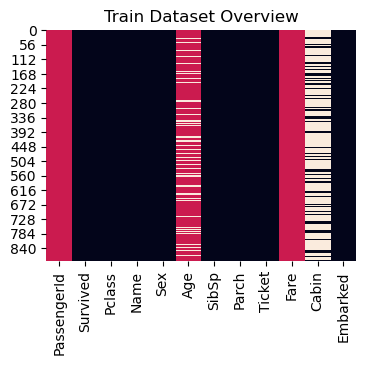

 Categerocial   Numeric   NaN 


In [20]:
### Visualization solution to detect missing values
dic_cols = {col:utils_recognize_type(df_train, col, max_cat=10) for col in df_train.columns}
heatmap = df_train.isnull()
for k,v in dic_cols.items():
    if v == "num":
        heatmap[k] = heatmap[k].apply(lambda x: 0.5 if x is False else 1)
    else:
        heatmap[k] = heatmap[k].apply(lambda x: 0 if x is False else 1)
figure(figsize=(4, 3))
sns.heatmap(heatmap, cbar=False).set_title('Train Dataset Overview')
plt.show()
print("\033[1;37;40m Categerocial ", "\033[1;30;41m Numeric ", "\033[1;30;47m NaN ")



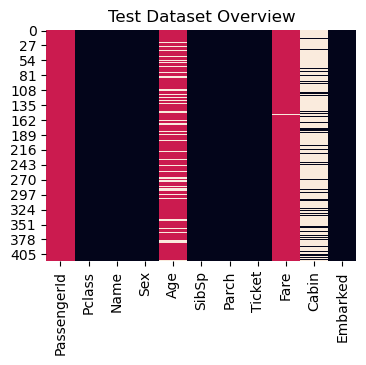

 Categerocial   Numeric   NaN 


In [21]:
dic_cols = {col:utils_recognize_type(df_test, col, max_cat=10) for col in df_test.columns}
heatmap = df_test.isnull()
for k,v in dic_cols.items():
    if v == "num":
        heatmap[k] = heatmap[k].apply(lambda x: 0.5 if x is False else 1)
    else:
        heatmap[k] = heatmap[k].apply(lambda x: 0 if x is False else 1)
figure(figsize=(4, 3))        
sns.heatmap(heatmap, cbar=False).set_title('Test Dataset Overview')
plt.show()
print("\033[1;37;40m Categerocial ", "\033[1;30;41m Numeric ", "\033[1;30;47m NaN ")

**Observation**
- For training data the next three columns 'Cabin', 'Age' and 'Embarked' have missing values.
- For testing data the next three columns 'Cabin', 'Age' and 'Fare' have missing values

#### Let's check the number of missing values

In [22]:
### Training data 
df_train.isnull().sum().sort_values(ascending=False)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
SibSp            0
Parch            0
Ticket           0
Fare             0
dtype: int64

In [23]:
### Testing data 
df_test.isnull().sum().sort_values(ascending=False)

Cabin          327
Age             86
Fare             1
PassengerId      0
Pclass           0
Name             0
Sex              0
SibSp            0
Parch            0
Ticket           0
Embarked         0
dtype: int64

##### b.Removing and Imputing missing values
- Deleting missing values from our data or keep them depends on some factors and the specific situations such as the nature of the missing data, its impact on the model, the data size, percentage of missing values  and finally data integrity.
- Here are some considerations:
   - **Nature of Missing Data:** are they random ?, or related to certain characteristics of the data ? or are related to the target variable. 
   - **Impact on Model:** missing values in :
      - Training data may impact the training process and the quality of the resulting models.
      - Testing data might affect the evaluation of the model's performance.
  
   - **Choosing the appropriate strategy:** 
      - Removing only rows with missing values. 
      - Removing the entire column.
      - Imputate them with the adequate value: mean, median Forward Fill/Backward Fill or predictive imputation.
      
  - **Maintaining data integrity:**  is deleting missing values would significantly reduce the dataset size so it is better to use an imputation strategy.
--------------------------------      
**Do not forget:**
- If missing values are common in real-world scenarios, it's best to keep them in the testing data.

-------------------------------------

#### My Solution:
I have identified missing values in four columns of the dataset. For each column, I will evaluate the best approach to handle these missing values individually.
- For training data :
  - Cabin : 687 missing values from 891 : it is better to delete the entire column.
  - Age : 177 missing values from 891 : impute them with median.
  - Embarked : only two values are missing: impute them with mode.
- For testing data:
  - Cabin column will be removed
  - 86 Null values are in Age column: I will impute them with median.
  - Fare has only one missing value, impute it with median.


In [24]:
df_train.drop('Cabin', axis=1,inplace=True) # delete cabin
#df_train.dropna(subset=["Embarked"], inplace=True)

#### Question: How to choose between using mean or median imputation?
- Briefly, median imputation is a better choice as median value is less affected by extreme values compared to the mean and it is more resilient to Skewness. 
- Actually mean imputation is more used when the data is normally distributed and does not have significant outliers.
- It is important to check skewness, kurtosis and distribution plots.

In [25]:
median = df_train["Age"].median()
mean = df_train["Age"].mean()
print('Mean Age:',mean)
print('Median Age:',median)

Mean Age: 29.69911764705882
Median Age: 28.0


In [26]:
df_train["Age"] = df_train["Age"].fillna(df_train["Age"].median())
df_train["Embarked"] = df_train["Embarked"].fillna(df_train["Embarked"].mode()[0])

In [27]:
### For testing data 
median = df_test["Fare"].median()
mean = df_test["Fare"].mean()
print('Mean Fare:',mean)
print('Median Fare:',median)

Mean Fare: 35.6271884892086
Median Fare: 14.4542


In [28]:
df_test.drop('Cabin', axis=1,inplace=True )
df_test["Age"] = df_test["Age"].fillna(df_test["Age"].median())
df_test["Fare"] = df_test["Fare"].fillna(df_test["Fare"].median())

**Second check:**

In [29]:
df_train.isnull().sum().sort_values(ascending=False)

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [30]:
df_test.isnull().sum().sort_values(ascending=False)

PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [31]:
df_train.shape

(891, 11)

In [32]:
df_test.shape

(418, 10)

#### 2.6- Check skewness and kurtosis
- Skewness and Kurtosis helps to check the shape and distribution of your data to understand its normality and detect outliers.
- **Skewness:**
   - Provides insights into the shape of a distribution: normal or skewed?
   - It uses data distribution asymmetry measurements for that. 
- **Kurtosis:**
   - Describes the shape or "tailedness" of a distribution. 
   - Determine if the data heavy-tailed or light-tailed than a normal distribution.
   
**! skewness and kurtosis are statistical measures that can only be calculated and interpreted for numerical data**

In [33]:
num_columns=['Age', 'Fare']
result = check_skewness_kurtosis(df_train, num_columns)
result

{'Age': {'skewness': 0.5093852558219663, 'kurtosis': 0.9815760369363544},
 'Fare': {'skewness': 4.7792532923723545, 'kurtosis': 33.20428925264474}}

**Observation:**
- Age:
   - The skewness value is 0.51: data is not highly skewed and it is moderately right-skewed.
   - The kurtosis value is 0.98: it is less then 3 (normal distribution kurtosis) so we have fewer outliers and Light Tails

- Fare: 
   - The skewness value is 4.77: indicates a strong right-skewed distribution with a very long tail on the right side.
   - The Kurtosis value is 33.2 : the distribution has very heavy tails and a sharp peak. 

In [34]:
num_columns=['Age', 'Fare']
result = check_skewness_kurtosis(df_test, num_columns)
result

{'Age': {'skewness': 0.6583735718880065, 'kurtosis': 0.8986526444812046},
 'Fare': {'skewness': 3.679035618763401, 'kurtosis': 17.741843957882192}}

**Observation:**
- Age:
   - The skewness value is 0.65: indicates a moderate right-skewed distribution, where the data has a longer tail on the right side compared to the left.
   - The kurtosis value is 0.98: a distribution that is slightly less peaked and has lighter tails compared to a normal distribution.

- Fare: 
   - The skewness value is 3.68: indicates a highly right-skewed distribution with very long tail on the right side. 
   - The Kurtosis value is 33.2 : it has heavy tails, a sharper peak around the mean and more extreme values compared to a normal distribution. 

#### 2.7- Handling the Outliers

- Outliers are data points that significantly differ from the rest.
- They can affect our analysis by causing variations in results, potentially leading to incorrect conclusions.
- Many reasons are behind outliers appearance  such as mistakes during data collection by humans, inaccuracies in the instruments used for data collection, errors introduced during data processing or outliers that occur naturally in the data, not as a result of any error.
- Handling outliers concerns both continuous numerical variables or categorical variable or Mixed-type data.

---------------------------------------------------
#### a. Finding the Outliers

- Here are the common approaches used to detect or to find the outliers :
   - **Visualization Techniques:** the most used statistical plots are Box Plot, Scatter Plot and Histogram Plot.
   - **Statistical Methods:** such as Z-Score, Modified Z-Score or Interquartile Range (IQR).
   - **Machine Learning** Anomaly detection algorithms such as Isolation Forest or One-class SVM
-------------------
#### For Continuous Numerical Variables
- Here are the existing columns : 
  - PassengerId : not considered
  - Age 
  - Fare

Text(0, 0.5, 'Density')

<Figure size 640x480 with 0 Axes>

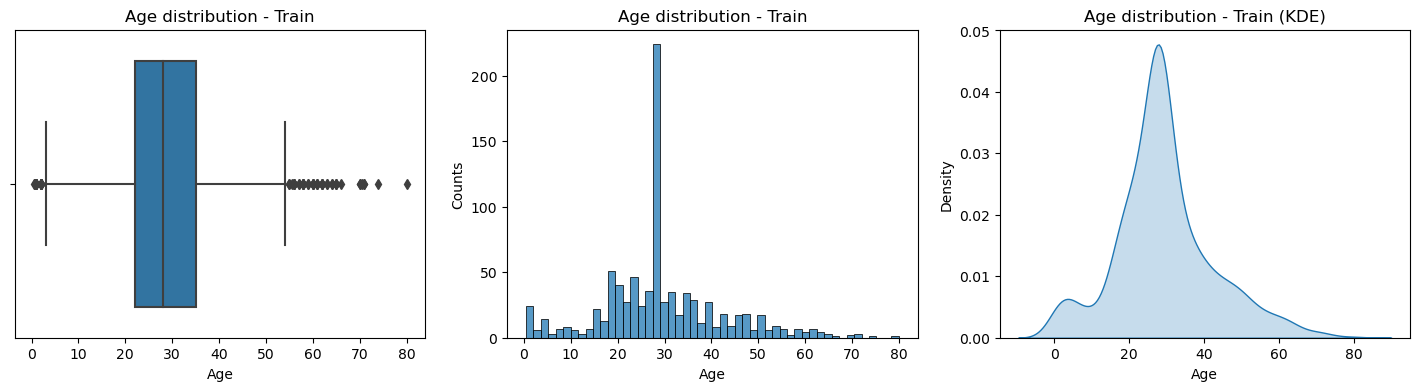

In [35]:
### Box plot for Training data
plt.figure()
figure(figsize=(18, 4))
#Box plot of Age
plt.subplot(1,3,1)
sns.boxplot(x=df_train['Age'])
plt.title('Age distribution - Train')

# Histogram of Age
plt.subplot(1,3,2)
sns.histplot(df_train['Age'], bins=50, kde=False)
plt.title('Age distribution - Train')
plt.xlabel('Age')
plt.ylabel('Counts')

# KDE plot of Age
plt.subplot(1,3,3)
sns.kdeplot(df_train['Age'], fill=True)
plt.title('Age distribution - Train (KDE)')
plt.xlabel('Age')
plt.ylabel('Density')

Text(0, 0.5, 'Density')

<Figure size 640x480 with 0 Axes>

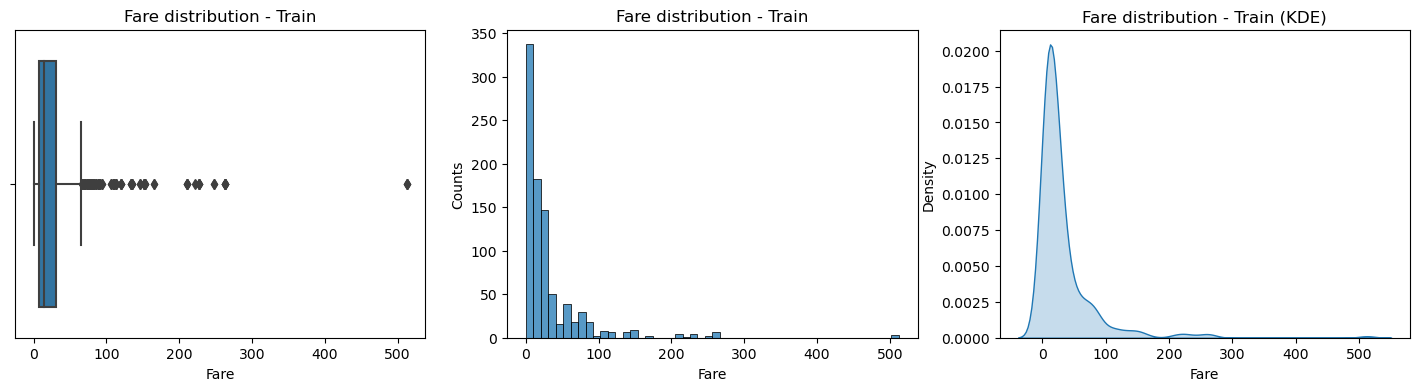

In [36]:
### Box plot for Training data
plt.figure()
figure(figsize=(18, 4))
#Box plot of Fare
plt.subplot(1,3,1)
sns.boxplot(x=df_train['Fare'])
plt.title('Fare distribution - Train')

# Histogram of Fare
plt.subplot(1,3,2)
sns.histplot(df_train['Fare'], bins=50, kde=False)
plt.title('Fare distribution - Train')
plt.xlabel('Fare')
plt.ylabel('Counts')

# KDE plot of Fare
plt.subplot(1,3,3)
sns.kdeplot(df_train['Fare'], fill=True)
plt.title('Fare distribution - Train (KDE)')
plt.xlabel('Fare')
plt.ylabel('Density')

I employed the Interquartile Range (IQR) method to calculate outliers percentage in the dataset.

In [37]:
### Calculate the percentage of outliers - Train
for column in num_columns:
    data = df_train[column]
    percent = str(round(outlier_percent(data), 2))
    print(f'Train: outliers in:"{column}": {percent}%')

Train: outliers in:"Age": 7.41%
Train: outliers in:"Fare": 13.02%


**Observation on Train data:**
- From the distribution plots (Histogram and KDE) above, it is clear that:
  - 'Age' : data does not follow a normal distribution; it is moderately right-skewed, with a longer tail on the right side compared to the left. Additionally, the data contains 7.41% outliers. Therefore, **the simplest and most effective method to handle null values is to replace them with the median.**
  - 'Fare':  has a strongly right-skewed distribution with an extended tail on the right side. It exhibits heavy tails and a sharp peak around the mean, indicating a high concentration of values around the mean with 13.02% outliers. Again **the median is the best and simplest method to handle null values.**

Text(0, 0.5, 'Density')

<Figure size 640x480 with 0 Axes>

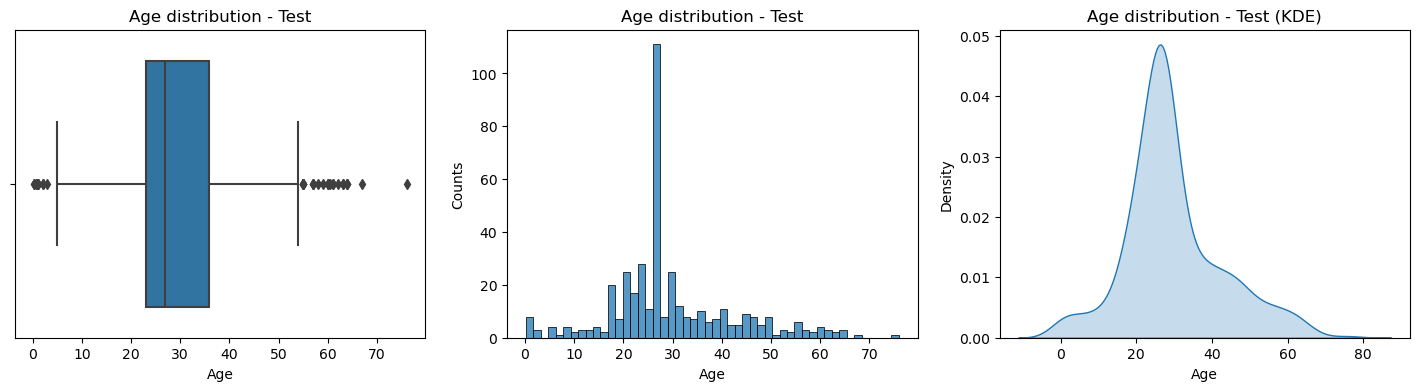

In [38]:
### Box plot for Testing data
plt.figure()
figure(figsize=(18, 4))
#Box plot of Age
plt.subplot(1,3,1)
sns.boxplot(x=df_test['Age'])
plt.title('Age distribution - Test')

# Histogram of Age
plt.subplot(1,3,2)
sns.histplot(df_test['Age'], bins=50, kde=False)
plt.title('Age distribution - Test')
plt.xlabel('Age')
plt.ylabel('Counts')

# KDE plot of Age
plt.subplot(1,3,3)
sns.kdeplot(df_test['Age'], fill=True)
plt.title('Age distribution - Test (KDE)')
plt.xlabel('Age')
plt.ylabel('Density')

Text(0, 0.5, 'Density')

<Figure size 640x480 with 0 Axes>

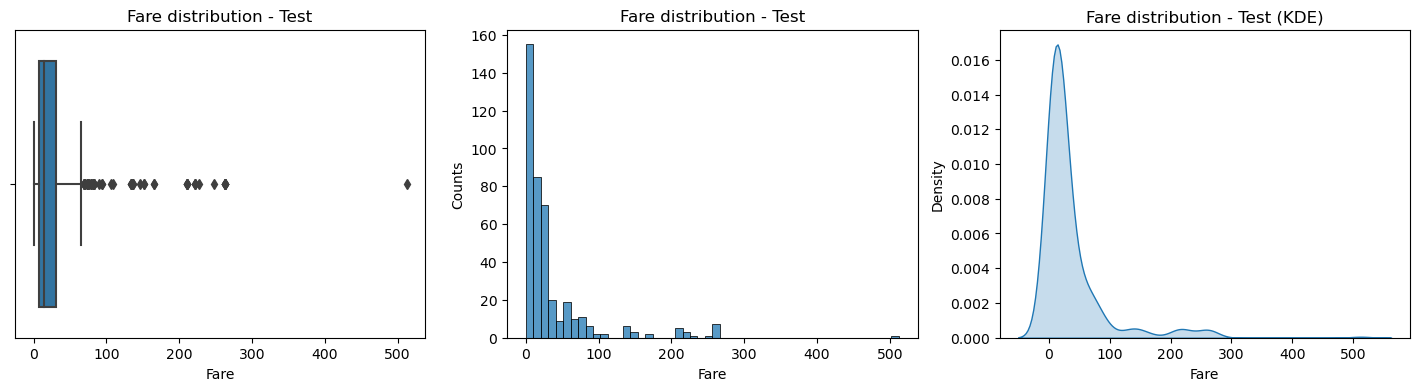

In [39]:
### Box plot for Testing data
plt.figure()
figure(figsize=(18, 4))
#Box plot of Fare
plt.subplot(1,3,1)
sns.boxplot(x=df_test['Fare'])
plt.title('Fare distribution - Test')

# Histogram of Fare
plt.subplot(1,3,2)
sns.histplot(df_test['Fare'], bins=50, kde=False)
plt.title('Fare distribution - Test')
plt.xlabel('Fare')
plt.ylabel('Counts')

# KDE plot of Fare
plt.subplot(1,3,3)
sns.kdeplot(df_test['Fare'], fill=True)
plt.title('Fare distribution - Test (KDE)')
plt.xlabel('Fare')
plt.ylabel('Density')

In [40]:
### Calculate the percentage of outliers - Testing
for column in num_columns:
    data = df_test[column]
    percent = str(round(outlier_percent(data), 2))
    print(f'Test: outliers in "{column}": {percent}%')

Test: outliers in "Age": 8.61%
Test: outliers in "Fare": 13.16%


**Observation on Test data:**
- From the distribution plots (Histogram and KDE) above, it is clear that:
  - 'Age' : data does not follow a normal distribution; it is moderately right-skewed, with a longer tail on the right side compared to the left. Additionally, the data contains 8.61% outliers. Again, **median is used to handle NaN**
  - 'Fare':  has a strongly right-skewed distribution with an extended tail on the right side. It exhibits a sharp peak around the mean, indicating a high concentration of values around the mean with 13.16% outliers. Again, **median is used to handle NaN**

### Decision regarding outliers : 
- To ensure transparency in reporting and interpreting results, I have chosen to retain outliers in my analysis, as they can offer valuable insights.
- Specifically, for Age, I believe it's important to include individuals from all age groups, including children and the elderly which are definitely few on the trip. Regarding fare, while 13% outliers may seem high, it is influenced by the varying ticket classes where lower-class tickets have significantly lower prices compared to a few higher-class tickets.
- Again, thie decision is to maintain data integrity and accurately reflect the population.

#### For Categorical Variables
- Categories that appear very infrequently may be considered outliers.
- Here are the existing columns: 
  - Survived ==> we will see it later
  - Pclass
  - SibSp
  - Sex
  - Parch
  - Embarked
  - Ticket
  
**My decision:**
The same approach will be applied to categorical data, but first, let's explore the presence of outliers in this context.

In [41]:
threshold=2
cat_columns=['Pclass', 'Sex', 'Embarked', 'SibSp', 'Parch']

In [42]:
# Apply the function to each categorical column - Training
for column in cat_columns:
    rare_categories = identify_rare_categories(df_train[column], threshold)
    print(f"Train: rare categories in {column}: {rare_categories}")

Train: rare categories in Pclass: []
Train: rare categories in Sex: []
Train: rare categories in Embarked: []
Train: rare categories in SibSp: []
Train: rare categories in Parch: [6]


In [43]:
Parch_count_train=df_train['Parch'].value_counts().to_frame()
Parch_count_train

,Parch
0,678
1,118
2,80
5,5
3,5
4,4
6,1


In [44]:
# Apply the function to each categorical column - Testing
for column in cat_columns:
    rare_categories = identify_rare_categories(df_test[column], threshold)
    print(f"Test: rare categories in {column}: {rare_categories}")

Test: rare categories in Pclass: []
Test: rare categories in Sex: []
Test: rare categories in Embarked: []
Test: rare categories in SibSp: [5]
Test: rare categories in Parch: [6, 5]


In [45]:
Parch_count_test=df_test['Parch'].value_counts().to_frame()
Parch_count_test

,Parch
0,324
1,52
2,33
3,3
4,2
9,2
6,1
5,1


In [46]:
SibSp_count_test=df_test['SibSp'].value_counts().to_frame()
SibSp_count_test

,SibSp
0,283
1,110
2,14
3,4
4,4
8,2
5,1


### 2.7- More data analysis and Visialization

**Question 1:  What is the count of survived and died Passengers?**
##### Checking class imbalance

In [47]:
train_label=df_train.Survived
class_0=np.where(train_label==0)# Died
class_1=np.where(train_label==1) # Survived
print('The number of survived is :',len(class_1[0]))
print('The number of died is :',len(class_0[0]))

The number of survived is : 342
The number of died is : 549


<Figure size 640x480 with 0 Axes>

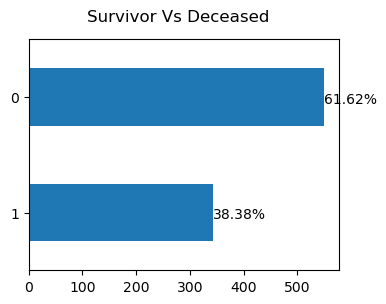

In [48]:
plt.figure()
figure(figsize=(4, 3))
ax = train_label.value_counts().sort_values().plot(kind="barh")
totals= []
for i in ax.patches:
    totals.append(i.get_width())
total = sum(totals)
for i in ax.patches:
     ax.text(i.get_width()+.3, i.get_y()+.20, 
     str(round((i.get_width()/total)*100, 2))+'%', 
     fontsize=10, color='black')
#ax.grid(axis="x")
plt.suptitle('Survivor Vs Deceased', fontsize=12)
plt.show()

**Observation:** the histogram above, indicates that 61% of passengers did not survive, whereas 38% survived.

In [49]:
train_label.value_counts().sort_values()

1    342
0    549
Name: Survived, dtype: int64

**Question 2: How is the gender distribution among passengers ?**

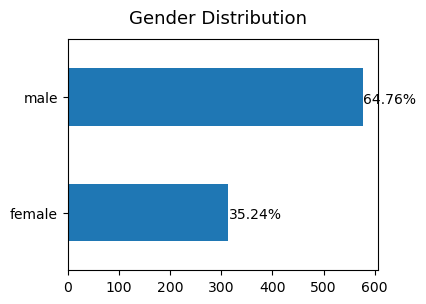

In [59]:
plt.figure(figsize=(4, 3))
#ax=DF_gr_Sex.plot.barh(x='Sex', y='PassengerId')
ax=df_train.Sex.value_counts().sort_values().plot(kind="barh")
totals= []
for i in ax.patches:
    totals.append(i.get_width())
total = sum(totals)
for i in ax.patches:
     ax.text(i.get_width()+.3, i.get_y()+.20, 
     str(round((i.get_width()/total)*100, 2))+'%', 
     fontsize=10, color='black')
#ax.grid(axis="x")
plt.suptitle('Gender Distribution', fontsize=13)
plt.show()

**Observation:** from the histogram above, it's evident that there were more males on the trip than females.

**Question 3: What is the number of tickets, Ticket classes and Embarkation Ports?**

In [51]:
#Training data
df_train.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Embarked         3
dtype: int64

In [52]:
# Testing data
df_test.nunique()

PassengerId    418
Pclass           3
Name           418
Sex              2
Age             79
SibSp            7
Parch            8
Ticket         363
Fare           169
Embarked         3
dtype: int64

In [53]:
df_train.shape

(891, 11)

In [54]:
df_test.shape

(418, 10)

**Observation:**
- Train: out of 891 passengers, there are only 681 unique tickets in the dataset, indicating that some passengers share tickets, which is common among families or couples traveling together.
- Test: the same here only 363 unique tickets out of 418 passengers.

**Question 4: What is the number of Survived/Died person per Sex ?**

In [55]:
DF_Survived=df_train[df_train.Survived==1]
DF_Died=df_train[df_train.Survived==0]
Su_gr_Sex=DF_Survived.groupby(['Sex']).count()
Su_gr_Sex=Su_gr_Sex.reset_index(level=['Sex'],drop=False)
Di_gr_Sex=DF_Died.groupby(['Sex']).count()
Di_gr_Sex=Di_gr_Sex.reset_index(level=['Sex'],drop=False)

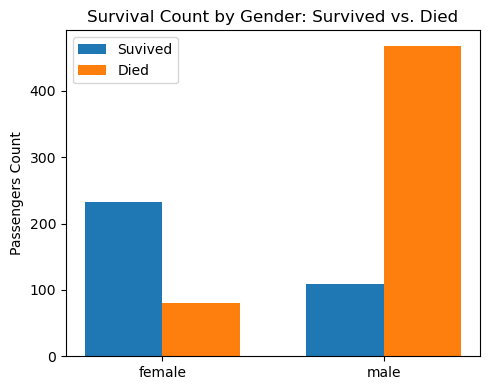

In [56]:
width = 0.35
labels=['female','male']
x = np.arange(len(labels)) 
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(x - width/2, Su_gr_Sex.PassengerId, width, label='Suvived')
ax.bar(x + width/2, Di_gr_Sex.PassengerId, width, label='Died')
# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Passengers Count')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_title('Survival Count by Gender: Survived vs. Died')
ax.legend()
fig.tight_layout()
plt.show()

**Observation:** the plot above, shows that more females 74.2% (233 from 314), survived the Titanic trip, while a higher number of males died 81.1% (468 from 577).

In [60]:
df_train.Sex.value_counts().sort_values()

female    314
male      577
Name: Sex, dtype: int64

In [61]:
Su_gr_Sex[['Sex', 'PassengerId']]

,Sex,PassengerId
0,female,233
1,male,109


In [62]:
Di_gr_Sex[['Sex', 'PassengerId']]

,Sex,PassengerId
0,female,81
1,male,468


**Question 5: What is the distribution of survival status (survived vs. died) across different ticket classes?**

In [63]:
Su_gr_Tclass=DF_Survived.groupby(['Pclass']).count()
Su_gr_Tclass=Su_gr_Tclass.reset_index(level=['Pclass'],drop=False)
Di_gr_Tclass=DF_Died.groupby(['Pclass']).count()
Di_gr_Tclass=Di_gr_Tclass.reset_index(level=['Pclass'],drop=False)

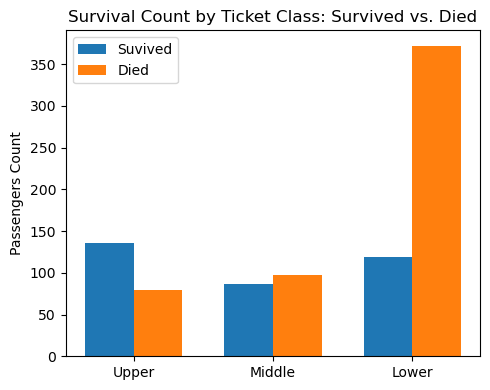

In [64]:
width = 0.35
labels=[ 'Upper', 'Middle', 'Lower']
x = np.arange(len(labels)) 
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(x - width/2, Su_gr_Tclass.PassengerId, width, label='Suvived')
ax.bar(x + width/2, Di_gr_Tclass.PassengerId, width, label='Died')
# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Passengers Count')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_title('Survival Count by Ticket Class: Survived vs. Died')
ax.legend()
fig.tight_layout()
plt.show()

In [65]:
Di_gr_Tclass[['Pclass', 'PassengerId']]

,Pclass,PassengerId
0,1,80
1,2,97
2,3,372


In [66]:
Su_gr_Tclass[['Pclass', 'PassengerId']]

,Pclass,PassengerId
0,1,136
1,2,87
2,3,119


In [67]:
# 1 = 1st (Upper), 2 = 2nd (Middle), 3 = 3rd (Lower)
df_train.Pclass.value_counts().sort_values()

2    184
1    216
3    491
Name: Pclass, dtype: int64

**Observation:** 

- A higher proportion of passengers who died belonged to the Lower class which is the Class 3, comprising 372 out of 491 (75.76%), compared to the Upper Class the Class 1, comprising 80 out of 216 (37%), or Middle class (50.71%).


**Question 6: How is the distribution of survival status (survived vs. died) distributed across different age groups??**

In [68]:
Su_gr_Age=DF_Survived.groupby(['Age']).count()
Su_gr_Age=Su_gr_Age.reset_index(level=['Age'],drop=False)
Di_gr_Age=DF_Died.groupby(['Age']).count()
Di_gr_Age=Di_gr_Age.reset_index(level=['Age'],drop=False)
Count_per_Age=df_train.groupby(['Age']).count()
Count_per_Age=Count_per_Age.reset_index(level=['Age'],drop=False)

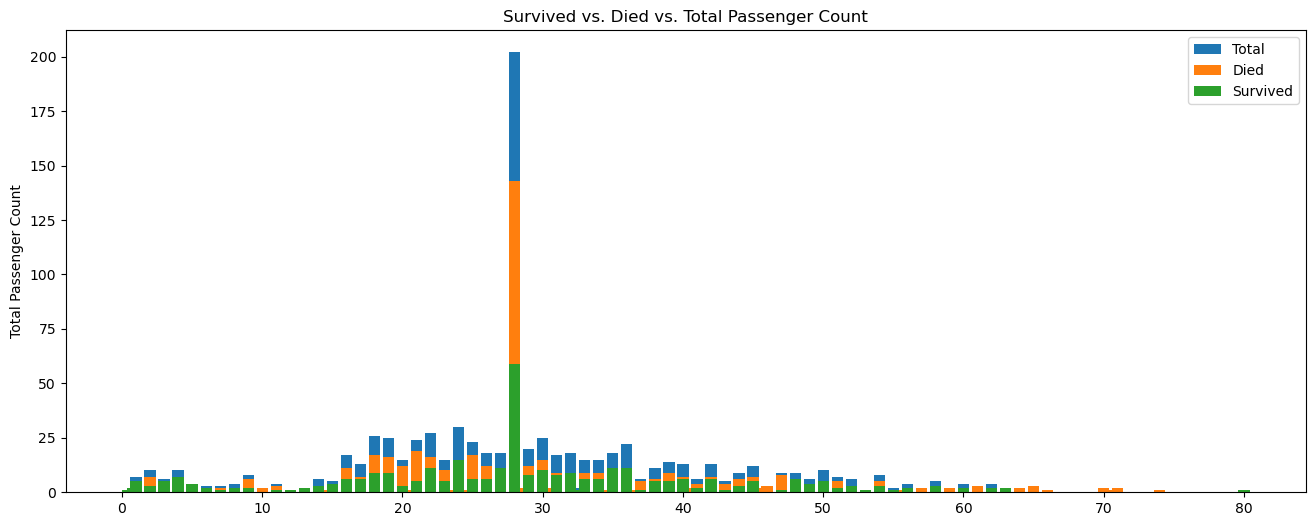

In [69]:
width = 0.8
fig, ax = plt.subplots(figsize=(16,6))
#ax.bar(Total_DF_gr.Age, Total_DF_gr.PassengerId,width, label='Total')
ax.bar(Count_per_Age.Age, Count_per_Age.PassengerId, width, label='Total') #the distribution of passengers across different age groups
ax.bar(Di_gr_Age.Age, Di_gr_Age.PassengerId, width, label='Died')
ax.bar(Su_gr_Age.Age, Su_gr_Age.PassengerId, width, label='Survived')
# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Total Passenger Count')
ax.set_title('Survived vs. Died vs. Total Passenger Count')
ax.legend()

#### Perform data filtering by removing passengers with an age of 28 from the three datasets mentioned above.

In [70]:
Count_per_Age1=Count_per_Age[Count_per_Age.Age!=28]
Di_gr_Age1=Di_gr_Age[Di_gr_Age.Age!=28]
Su_gr_Age1=Su_gr_Age[Su_gr_Age.Age!=28]

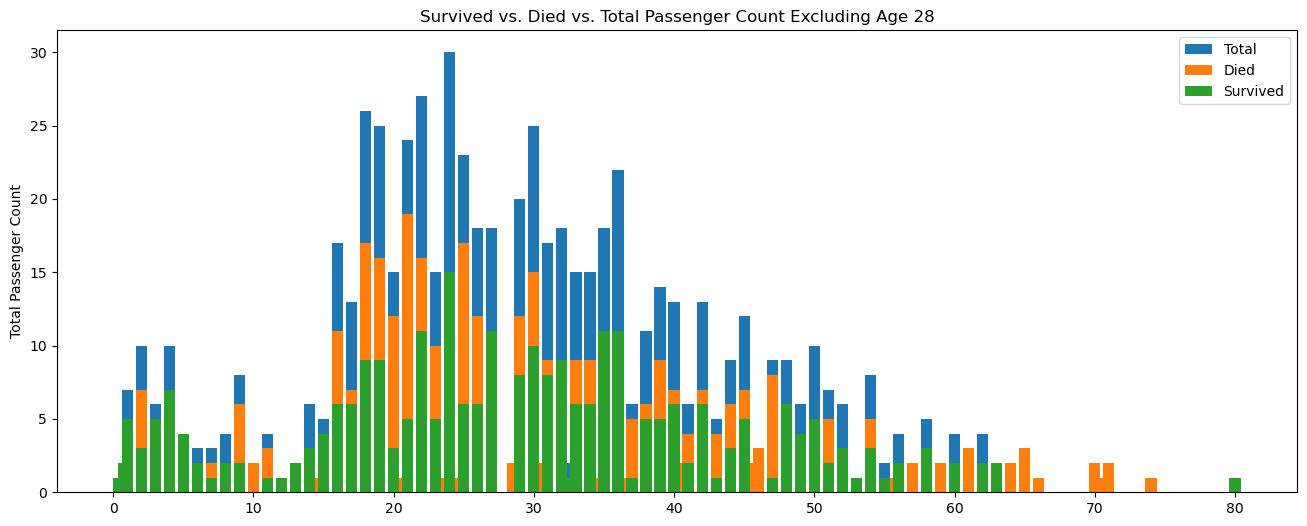

In [71]:
width = 0.8
fig, ax = plt.subplots(figsize=(16,6))
ax.bar(Count_per_Age1.Age, Count_per_Age1.PassengerId, width, label='Total') #the distribution of passengers across different age groups
ax.bar(Di_gr_Age1.Age, Di_gr_Age1.PassengerId, width, label='Died')
ax.bar(Su_gr_Age1.Age, Su_gr_Age1.PassengerId, width, label='Survived')
# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Total Passenger Count')
ax.set_title('Survived vs. Died vs. Total Passenger Count Excluding Age 28')
ax.legend()

In [72]:
df_train[df_train.Age==80]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
630,631,1,1,"Barkworth, Mr. Algernon Henry Wilson",male,80.0,0,0,27042,30.0,S


**Observations:** 
- Based on the plot above, the majority of passengers on the trip were between 16 and 36 years old, with the peak number of passengers at age 28.
- Survival rates varied across age groups: children aged 3 to 6 experienced no deaths, while all elderly passengers aged 64 to 75 did not survive.
- Additionally, all individuals aged 27 survived, and in general, most children survived.

**Question 7: What is the distribution of survival status (survived vs. died) across different Embarkation Ports?**

In [73]:
Su_gr_Port=DF_Survived.groupby(['Embarked']).count()
Su_gr_Port=Su_gr_Port.reset_index(level=['Embarked'],drop=False)
Di_gr_Port=DF_Died.groupby(['Embarked']).count()
Di_gr_Port=Di_gr_Port.reset_index(level=['Embarked'],drop=False)

In [74]:
# Sorting by column 'PassengerId'
Di_gr_Port=Di_gr_Port.sort_values(by=['PassengerId'])
Su_gr_Port=Su_gr_Port.sort_values(by=['PassengerId'])

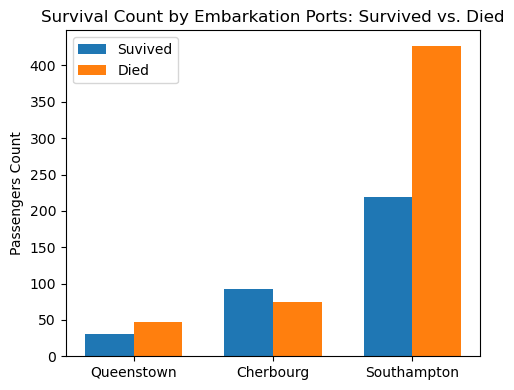

In [75]:
width = 0.35
#C = Cherbourg, Q = Queenstown, S = Southampton
labels=['Queenstown', 'Cherbourg',  'Southampton']
x = np.arange(len(labels)) 
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(x - width/2, Su_gr_Port.PassengerId, width, label='Suvived')
ax.bar(x + width/2, Di_gr_Port.PassengerId, width, label='Died')
# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Passengers Count')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_title('Survival Count by Embarkation Ports: Survived vs. Died')
ax.legend()
fig.tight_layout()
plt.show()

In [76]:
Di_gr_Port[['Embarked', 'PassengerId']]

,Embarked,PassengerId
1,Q,47
0,C,75
2,S,427


In [77]:
Su_gr_Port[['Embarked', 'PassengerId']]

,Embarked,PassengerId
1,Q,30
0,C,93
2,S,219


In [78]:
df_train.Embarked.value_counts().sort_values()

Q     77
C    168
S    646
Name: Embarked, dtype: int64

**Observations:**
- From the histogram above, it is clear that most passengers embarked from Southampton (646), followed by Cherbourg (168) and Queenstown (77). Additionally, the majority of passengers who died were from Southampton.
- 66.1% of people who embarked from Southampton died, while 61.04% of those who embarked from Queenstown died.

**Question 8: What is the distribution of survival status (survived vs. died) across different numbers of parents and children aboard the Titanic?**

In [79]:
Su_gr_Parch=DF_Survived.groupby(['Parch']).count()
Su_gr_Parch=Su_gr_Parch.reset_index(level=['Parch'],drop=False)
Di_gr_Parch=DF_Died.groupby(['Parch']).count()
Di_gr_Parch=Di_gr_Parch.reset_index(level=['Parch'],drop=False)

In [80]:
Su_gr_Parch=Su_gr_Parch[['Parch', 'PassengerId']]
Di_gr_Parch=Di_gr_Parch[['Parch', 'PassengerId']]
# Manually add an extra row
row1 = pd.Series(['6', 0], index=['Parch', 'PassengerId'])
row2 = pd.Series(['4', 0], index=['Parch', 'PassengerId'])
Su_gr_Parch = Su_gr_Parch.append([row1,row2], ignore_index=True)
## Convert column and sort it
Su_gr_Parch['Parch']=Su_gr_Parch['Parch'].astype(int)
Su_gr_Parch.sort_values('Parch',inplace=True, ascending=True)

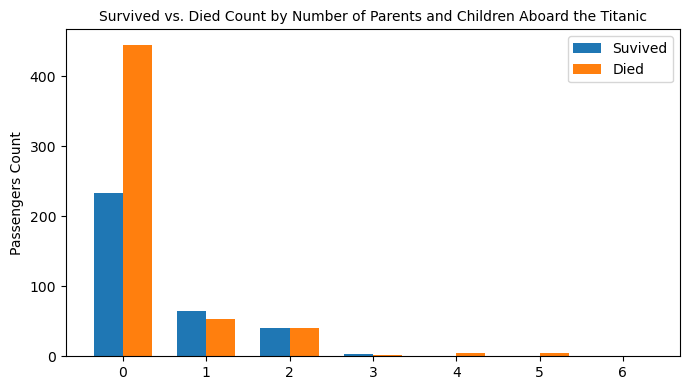

In [81]:
width = 0.35
labels=['0', '1', '2', '3', '4', '5', '6']
x = np.arange(len(labels)) 
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - width/2, Su_gr_Parch.PassengerId, width, label='Suvived')
ax.bar(x + width/2, Di_gr_Parch.PassengerId, width, label='Died')
# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Passengers Count')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_title('Survived vs. Died Count by Number of Parents and Children Aboard the Titanic', fontsize=10)
ax.legend()
fig.tight_layout()
plt.show()

In [82]:
Di_gr_Parch

,Parch,PassengerId
0,0,445
1,1,53
2,2,40
3,3,2
4,4,4
5,5,4
6,6,1


In [83]:
Su_gr_Parch

,Parch,PassengerId
0,0,233
1,1,65
2,2,40
3,3,3
6,4,0
4,5,1
5,6,0


In [84]:
df_train.Parch.value_counts().sort_values()

6      1
4      4
5      5
3      5
2     80
1    118
0    678
Name: Parch, dtype: int64

**Observations:**
- Most passengers did not have parents / children aboard the trip.
- All passengers with 4 or 6 parents / children aboard died.
- Only 34.37% of people with no parents / children aboard survived.
- Additionally, 50% of passengers with 2 parents / children aboard died.

**Question 9: What is the distribution of survival status (survived vs. died) across different numbers of siblings and spouses aboard the Titanic?**

In [85]:
Su_gr_SibSp=DF_Survived.groupby(['SibSp']).count()
Su_gr_SibSp=Su_gr_SibSp.reset_index(level=['SibSp'],drop=False)
Di_gr_SibSp=DF_Died.groupby(['SibSp']).count()
Di_gr_SibSp=Di_gr_SibSp.reset_index(level=['SibSp'],drop=False)

In [86]:
Su_gr_SibSp=Su_gr_SibSp[['SibSp', 'PassengerId']]
Di_gr_SibSp=Di_gr_SibSp[['SibSp', 'PassengerId']]
# Manually add an extra row
row1 = pd.Series(['5', 0], index=['SibSp', 'PassengerId'])
row2 = pd.Series(['8', 0], index=['SibSp', 'PassengerId'])
Su_gr_SibSp = Su_gr_SibSp.append([row1,row2], ignore_index=True)
## Convert column and sort it
Su_gr_SibSp['SibSp']=Su_gr_SibSp['SibSp'].astype(int)
Su_gr_SibSp.sort_values('SibSp',inplace=True, ascending=True)

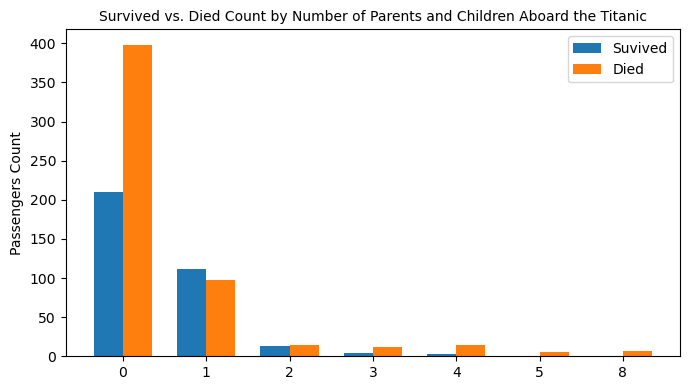

In [87]:
width = 0.35
labels = np.union1d(Su_gr_SibSp.SibSp.unique(), Di_gr_SibSp.SibSp.unique())
x = np.arange(len(labels)) 
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - width/2, Su_gr_SibSp.PassengerId, width, label='Suvived')
ax.bar(x + width/2, Di_gr_SibSp.PassengerId, width, label='Died')
# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Passengers Count')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_title('Survived vs. Died Count by Number of Parents and Children Aboard the Titanic', fontsize=10)
ax.legend()
fig.tight_layout()
plt.show()

In [88]:
Di_gr_SibSp

,SibSp,PassengerId
0,0,398
1,1,97
2,2,15
3,3,12
4,4,15
5,5,5
6,8,7


In [89]:
Su_gr_SibSp

,SibSp,PassengerId
0,0,210
1,1,112
2,2,13
3,3,4
4,4,3
5,5,0
6,8,0


In [90]:
df_train.SibSp.value_counts().sort_values()

5      5
8      7
3     16
4     18
2     28
1    209
0    608
Name: SibSp, dtype: int64

**Observations:**
- Most passengers did not siblings / spouses aboard the Titanic.
- All passengers with 5 or 8 siblings / spouses aboard died.
- Only 25% of people with 3 siblings/spouses aboard survived, while 50% of those with 2 siblings/spouses survived. 
- Additionally, almost 50% of passengers with 1 siblings / spouses aboard died.

### 3. Feature Engineering ⚙️
- The Feature Engineering phase aims to enhance model performance and can include the following tasks:
   - Feature selection
   - Feature encoding
   - Feature scaling
   - Creating new features
   
#### In this assignment, I decided to perform the following tasks:
  - Feature Selection : filter the most relevant columns.
  - Feature encoding : encoding categorical values to numeric variables.
  - Feature Scaling : using data standardization technique to transform data so that it has a zero mean and a standard deviation of one. This ensures that each feature contributes equally to the analysis and helps improve the performance and convergence of machine learning algorithms.

**Note:** Not all feature engineering tasks need to be performed in every data science project; it depends on various factors such as the nature of the data and the specific situation.

#### 3.1- Feature Selection 

In [91]:
df_train.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C


#### Note: I can either delete the irrelevant columns or select the relevant ones.

In [92]:
data_train=df_train[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]

In [93]:
data_test=df_test[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]

#### 3.2- Feature encoding 
- Feature encoding can be done using techniques like one-hot encoding, label encoding, or ordinal encoding etc. 
- The choice of technique depends on the nature of the categorical variable and the requirements of the analysis.
- This process is crucial because many algorithms require numerical input to function correctly.

In [94]:
df_train.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C


In [95]:
# Categorical columns in Train data
train_categorical_columns = data_train.select_dtypes(include=['object', 'category']).columns
train_categorical_columns

Index(['Sex', 'Embarked'], dtype='object')

In [96]:
# Categorical columns in Test data
test_categorical_columns = data_test.select_dtypes(include=['object', 'category']).columns
test_categorical_columns

Index(['Sex', 'Embarked'], dtype='object')

**My solution:**
- Only 'Sex' and 'Embarked' columns are identified as categorical columns and must be encoded.
- I decided to encode them using one-hot encoding with the `get_dummies` function from pandas.
- One-hot encoding, which creates a new binary column for each category, is the best and simplest choice for my case. The 'Sex' and 'Embarked' columns are nominal categorical variables with no inherent order or high cardinality.
- Additionally, since only two features need to be encoded, my dataset does not have high cardinality features overall.

In [97]:
## encoding Sex and Embarked columns in training data
df_onehot = pd.get_dummies(data_train, columns=['Sex','Embarked' ]) 
df_onehot.tail(2)

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
889,1,1,26.0,0,0,30.00,0,1,1,0,0
890,0,3,32.0,0,0,7.75,0,1,0,1,0


In [98]:
## encoding Sex and Embarked columns in testing data
#test_df_onehot = pd.get_dummies(data_test, columns=['Sex','Embarked' ]) 
#test_df_onehot.head(2)

#### 3.3- Feature scaling 
- It is often beneficial to scale the data before applying any machine learning algorithms, especially if the algorithm relies on distance-based calculations or regularization techniques. 
- Data scaling ensures that features contribute equally to the model and can improve convergence speed and overall performance.
- Several techniques can be used to scale features such as Z-score Normalization (Standardization), Min-Max Scaling (Normalization), Robust scaling etc.


-----------
#### My  solution regarding feature Scaling
- In this assignment, I have decided to use multiple classification algorithms while not all of them will benefit from feature scaling.
- Tree-based algorithms such as Decision Trees and Random Forests are generally not sensitive to feature scaling as they are based on splits and not distance calculations.
- I will use unscaled data for the algorithms mentioned earlier and for Logistic Regression. However, for Support Vector Machine and K-Nearest Neighbors, which rely on distance-based calculations, I will use scaled data.

In [99]:
df_onehot.head(3)

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,0,1,0,0,1
1,1,1,38.0,1,0,71.2833,1,0,1,0,0
2,1,3,26.0,0,0,7.9250,1,0,0,0,1


In [100]:
### To be executed later 
#scaler = StandardScaler()
#X_train_scaled = scaler.fit_transform(X_train)
#X_test_scaled = scaler.transform(X_test)

### 4. Model Building 🔎
- Model building involves selecting an appropriate algorithm, training the model on the training dataset and tuning hyperparameters to optimize performance.

- In this assignment, I've chosen to employ the following algorithms
  - Decision Trees 
  - Random Forest
  - Logistic Regression
  - Support Vector Machine
  - K-Nearest Neighbors

#### 4.1- Data splitting and final preparation 

In [101]:
df_train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')

In [102]:
df_train.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C


In [103]:
data=df_onehot.drop('Survived', axis=1)
label=df_onehot.Survived

In [104]:
data.shape

(891, 10)

In [105]:
X_train, X_test, y_train, y_test = train_test_split(data, label, test_size=0.2, random_state=42)

In [106]:
len(y_train)

712

#### 4.1- Decision Trees
##### Why I decided to use Decision Trees ?
- I chose to use decision trees because they are extensively used for classification tasks. Besides, they are simple because they are easy to understand, interpret, and visualize compared to many other complex machine learning models. 
- Non-parametric, so no assumptions about the underlying data distribution.
- In addition, it can effectively handle both numerical and categorical data.

**Note:**
- For all my models, I have used grid search in hyperparameter optimization to improve model performance, save time and enhance the reproducibility of the model. 
- It's generally a good practice to start with a simpler model then increase its complexity slowly while monitoring performance.

In [107]:
# Grid Search parameters 
paramG_DT={ 'criterion':['gini', 'entropy'], 'max_depth':[None, 10, 15, 20, 25], 
              'min_samples_split':[2,3,4,5,10], 'min_samples_leaf': [1, 2, 4],
             'max_features':[5,7,10,'auto', 'sqrt', 'log2', None],'splitter': ['best','random'], 
             }
DT=DecisionTreeClassifier(random_state = 42) # implementation of the hierarchical/decision trees
GS_DT=GridSearchCV(DT, paramG_DT, n_jobs=-1,cv=5, scoring='accuracy')
GS_DT.fit(X_train,y_train)
GS_DT.best_params_ 

{'criterion': 'entropy',
 'max_depth': 10,
 'max_features': 7,
 'min_samples_leaf': 1,
 'min_samples_split': 4,
 'splitter': 'best'}

In [108]:
BestGS_DT=GS_DT.best_params_ 

In [109]:
best_DTC=DecisionTreeClassifier(criterion=BestGS_DT['criterion'], max_depth=BestGS_DT['max_depth'],
                                max_features=BestGS_DT['max_features'], min_samples_split=BestGS_DT['min_samples_split'],
                                min_samples_leaf=BestGS_DT['min_samples_leaf'], splitter='random', random_state = 42)
best_DTC.fit(X_train, y_train)
# Evaluate on training data
train_preds_dt = best_DTC.predict(X_train)
# Evaluate on testing data
y_predDT=best_DTC.predict(X_test)

In [114]:
# Predict probabilities (y_predDT_probs) on test set
y_predDT_probs = best_DTC.predict_proba(X_test)[:, 1]


#### 4.2- Random Forest 
##### Why I decided to use  Random Forest ?
- It enhances accuracy via introduces diversity and reducing correlation among trees. 
- It has multiple trees that are trained independently and their predictions are combined through voting or averaging.
- This ensemble approach helps to reduce variance and overfitting, leading to better generalization and performance.
- Naturally handles class imbalance by giving equal importance to all classes during tree construction.


In [115]:
# Grid Search parameters 
paramG_RF = { 'criterion' :['gini', 'entropy'], 'n_estimators': [10, 20, 50, 100, 120], 
             'max_depth': [5, 10, 15, 20], 'min_samples_split':[2,4,6,10],
             'min_samples_leaf': [1, 2, 4], 'max_features': ['sqrt', 'log2']}
RF = RandomForestClassifier(random_state = 42)
GS_RF=GridSearchCV(RF, paramG_RF, n_jobs=-1,cv=5, scoring='accuracy')
GS_RF.fit(X_train,y_train)
GS_RF.best_params_ 

{'criterion': 'gini',
 'max_depth': 5,
 'max_features': 'sqrt',
 'min_samples_leaf': 1,
 'min_samples_split': 10,
 'n_estimators': 10}

In [116]:
BestGS_RF=GS_RF.best_params_ 

In [117]:
RF_best = RandomForestClassifier(random_state = 42, criterion=BestGS_RF['criterion'],
                                 max_features=BestGS_RF['max_features'], n_estimators=BestGS_RF['n_estimators'], 
                                max_depth=BestGS_RF['max_depth'], min_samples_leaf=BestGS_RF['min_samples_leaf'],
                                min_samples_split=BestGS_RF['min_samples_split'])
RF_best.fit(X_train, y_train)
# Evaluate on training data
train_preds_rf = RF_best.predict(X_train)
# Evaluate on testing data
y_predRF=RF_best.predict(X_test)


In [118]:
# Predict probabilities on test set
y_predRF_probs = RF_best.predict_proba(X_test)[:, 1]

#### 4.3- Logistic Regression
##### Why I decided to use  Logistic Regression ?
- It is proficient in binary classification problems.
- It provides probabilities for each class, offering insights into the confidence of predictions.
- It assumes a linear relationship between features and the outcome, better than decision trees in this points which may requires more complex splits
- It is computationally efficient and interpretable, providing straightforward insights into how each feature influences the predicted outcome.

In [119]:
# Grid Search parameters
paramG_LR = {'C': [0.001, 0.01, 0.1, 1, 10, 100],
              'solver':['liblinear', 'lbfgs'], 
              'penalty' : ['l1', 'l2', 'elasticnet'] } # discard 'none' as it might increase the risk of overfitting
Logis_R = LogisticRegression(random_state=42, max_iter=1000)
GS_LR=GridSearchCV(Logis_R, paramG_LR, n_jobs=-1,cv=5, scoring='accuracy')
GS_LR.fit(X_train,y_train)
GS_LR.best_params_ 

{'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}

In [120]:
BestGS_LR=GS_LR.best_params_ 

In [121]:
LR_best = LogisticRegression(random_state=42, C=BestGS_LR['C'],
                             penalty=BestGS_LR['penalty'], solver=BestGS_LR['solver'])
LR_best.fit(X_train, y_train)
# Evaluate on training data
train_preds_lr = LR_best.predict(X_train)
# Evaluate on testing data
y_predLR=LR_best.predict(X_test)

In [122]:
# Predict probabilities on test set
y_predLR_probs = LR_best.predict_proba(X_test)[:, 1]

### Data Scaling 

- I am going to proceed with scaling data as it can provides significant benefits to the model.
- Scaling data should be performed after splitting the dataset into training and testing sets to prevent data leakage and to ensure that scaling is learned solely from the training data. Then, it is applied to both sets.
- Scaling is typically applied to numerical features while Categorical features with qualitative discrete values, do not require scaling. 
- However, if categorical features are encoded into numerical form such as one-hot encoding, they do not need to be scaled since they are mapped into binary variables and they are already on the same scale (0 or 1).

**Note :** data leakage is the case where information from the test set might influence the training process. This violates the golden rule of machine learning—training and testing data should remain independent.

In [123]:
## Split numerical features from Categorical ones 
X_train_scaled=X_train
X_test_scaled=X_test
numerical_columns=['Age','Fare']

In [124]:
scaler = StandardScaler()
# Fit and transform numerical columns
X_train_scaled[numerical_columns] = scaler.fit_transform(X_train_scaled[numerical_columns])
X_test_scaled[numerical_columns] = scaler.transform(X_test_scaled[numerical_columns]) 

#### 4.4- Support vector Machine 
##### Why I decided to use  SVM ?
- Robust to Overfitting especially if we have noisy dataset
- It can model complex, non-linear relationships using different kernel functions.
- It is able to adapt to diverse data types via choosing the right kernel.
- It is distance-based algorithms that aims to maximise the margin between different classes. 

In [126]:
paramG_SVC = { 'kernel':['linear', 'rbf', 'sigmoid'],
               'gamma':['scale', 'auto'],
               'C': [0.001, 0.01, 0.1, 1, 10, 100]}
SVC = SVC(random_state=42, probability=True)
GS_SVC=GridSearchCV(SVC, paramG_SVC, n_jobs=-1,cv=5, scoring='accuracy')
GS_SVC.fit(X_train_scaled, y_train)
GS_SVC.best_params_

{'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}

In [127]:
BestGS_SVC=GS_SVC.best_params_ 

In [128]:
from sklearn.svm import SVC

In [129]:
SVC_best = SVC(probability=True, random_state=42, C=BestGS_SVC['C'],
               kernel=BestGS_SVC['kernel'], gamma=BestGS_SVC['gamma'])
SVC_best.fit(X_train_scaled, y_train)
# Evaluate on training data
train_preds_svc = SVC_best.predict(X_train)
# Evaluate on testing data
y_predSVC=SVC_best.predict(X_test_scaled)

In [130]:
# Predict probabilities on test set
y_predsvc_probs = SVC_best.predict_proba(X_test_scaled)[:, 1]

#### 4.5- K-Nearest Neighbors
##### Why I decided to use  KNN ?
- It handles non-linear relationships between features and the target class effectively.
- It's robust against noise and effective in scenarios where decision boundaries are straightforward.
- Suitable for datasets with a moderate number of samples where calculating distances is feasible.
- Can tolerate noisy data without significant impact on performance.
- It is has simple interpretability.

In [131]:
# Grid Search parameters
paramG_KNN ={'n_neighbors':[7,9,10,11,12, 13, 15], 'weights':['uniform', 'distance'], 
             'p': [1, 2], 'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
             'leaf_size':[10,20,30,50,60]}
KNN = KNeighborsClassifier()
GS_KNN=GridSearchCV(KNN, paramG_KNN, n_jobs=-1, cv=5, scoring='accuracy')
GS_KNN.fit(X_train_scaled,y_train)
GS_KNN.best_params_ 

{'algorithm': 'ball_tree',
 'leaf_size': 20,
 'n_neighbors': 11,
 'p': 1,
 'weights': 'uniform'}

In [132]:
BestGS_KNN=GS_KNN.best_params_

In [133]:
KNN_best = KNeighborsClassifier(n_neighbors=BestGS_KNN['n_neighbors'], weights=BestGS_KNN['weights'],
                                p=BestGS_KNN['p'], algorithm=BestGS_KNN['algorithm'],
                                leaf_size=BestGS_KNN['leaf_size'])
KNN_best.fit(X_train_scaled, y_train)
# Evaluate on training data
train_preds_knn = KNN_best.predict(X_train)
# Evaluate on testing data
y_predKNN=KNN_best.predict(X_test_scaled)

In [134]:
# Predict probabilities on test set
y_predknn_probs = KNN_best.predict_proba(X_test)[:, 1]

### 5. Model Evaluation 🏆
This step focuses on assessing the model's performance on unseen data. Here are key evaluation metrics to consider during this phase:
- Accuracy 
- Precision
- Recall
- F1 Score
- Confusion Matrix
- ROC Curve and AUC

**Note:**
- The choice of the evaluation metric depends on many factors such as the problem and class distribution as some metrics may be more relevant than others.
- For example, in imbalanced datasets, accuracy is not a reliable metric for models evaluation therefore, it is better to use precision and recall which are often more informative than accuracy.
- It's essential to choose metrics that align with our specific goals and interpret the results in the context of our problem.


#### 5.1- Decision Trees

In [135]:
#### Compute evaluation metrics ###
## Training 
# Accuracy: 
train_acc_dt = accuracy_score(y_train, train_preds_dt)
#precision
train_preci_dt = precision_score(y_train, train_preds_dt)
#recall 
train_recall_dt = recall_score(y_train, train_preds_dt)
# F1 score
train_f1_dt= f1_score(y_train, train_preds_dt)
# Classification Report
#train_class_report_dt = classification_report(y_train, train_preds_dt)

##################
## Testing
# Accuracy: 
acc_dt = accuracy_score(y_test, y_predDT)
#precision
preci_dt = precision_score(y_test, y_predDT)
#recall 
recall_dt = recall_score(y_test, y_predDT)
# F1 score
f1_dt= f1_score(y_test, y_predDT)
# ROC Curve and AUC
auc_roc_dt= roc_auc_score(y_test, y_predDT_probs)
# Confusion Matrix
conf_matrix_dt = confusion_matrix(y_test, y_predDT)
# Classification Report
class_report_dt = classification_report(y_test, y_predDT)

In [136]:
# Print the metrics
print('**********************')
print('Decition Tree Evaluation metrics')
print('**********************')
print('Training')
print('**********************')
print(f'Accuracy: {train_acc_dt}')
print(f'Precision: {train_preci_dt}')
print(f'Recall: {train_recall_dt}')
print(f'F1 Score: {train_f1_dt}')
print('**********************')
print('Testing')
print('**********************')
print(f'Accuracy: {acc_dt}')
print(f'Precision: {preci_dt}')
print(f'Recall: {recall_dt}')
print(f'F1 Score: {f1_dt}')
print(f'AUC-ROC: {auc_roc_dt}')
print(f'Confusion Matrix:\n{conf_matrix_dt}')
print(f'Classification Report:\n{class_report_dt}')

**********************
Decition Tree Evaluation metrics
**********************
Training
**********************
Accuracy: 0.8834269662921348
Precision: 0.9468599033816425
Recall: 0.7313432835820896
F1 Score: 0.8252631578947368
**********************
Testing
**********************
Accuracy: 0.7821229050279329
Precision: 0.7777777777777778
Recall: 0.6621621621621622
F1 Score: 0.7153284671532847
AUC-ROC: 0.8057915057915057
Confusion Matrix:
[[91 14]
 [25 49]]
Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.87      0.82       105
           1       0.78      0.66      0.72        74

    accuracy                           0.78       179
   macro avg       0.78      0.76      0.77       179
weighted avg       0.78      0.78      0.78       179



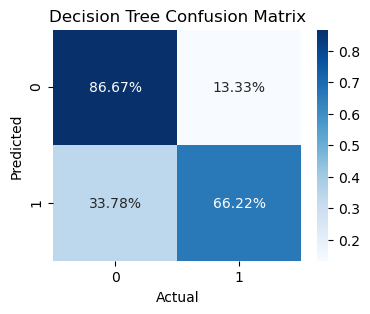

In [137]:
## Plot confusion matrix
# Normalize the confusion matrix to show percentages
plt.figure(figsize=(4, 3))
cm_normdt = conf_matrix_dt.astype('float') / conf_matrix_dt.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normdt, annot=True, fmt=".2%", cmap='Blues', xticklabels=['0', '1'], yticklabels=['0', '1'])
plt.ylabel('Predicted')
plt.xlabel('Actual')
plt.title('Decision Tree Confusion Matrix')
plt.show()

In [138]:
# ROC Curve
fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test, y_predDT_probs)

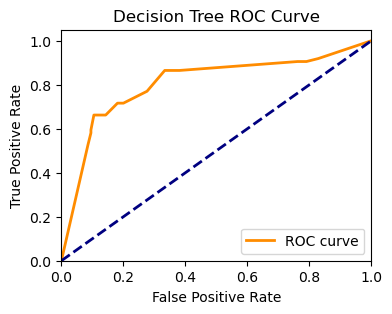

In [139]:
# Plot ROC Curve
plt.figure(figsize=(4, 3))
plt.plot(fpr_dt, tpr_dt, color='darkorange', lw=2, label='ROC curve')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Decision Tree ROC Curve')
plt.legend(loc='lower right')
plt.show()

#### 5.2-Random Forest

In [140]:
#### Compute evaluation metrics ###
## Training 
# Accuracy: 
train_acc_rf = accuracy_score(y_train, train_preds_rf)
#precision
train_preci_rf = precision_score(y_train, train_preds_rf)
#recall 
train_recall_rf = recall_score(y_train, train_preds_rf)
# F1 score
train_f1_rf= f1_score(y_train, train_preds_rf)
# Classification Report
#train_class_report_rf = classification_report(y_train, train_preds_rf)

## Testing
# Accuracy: 
acc_rf = accuracy_score(y_test, y_predRF) 
#precision
preci_rf = precision_score(y_test, y_predRF)
#recall 
recall_rf = recall_score(y_test, y_predRF)
# F1 score
f1_rf= f1_score(y_test, y_predRF)
# ROC Curve and AUC
auc_roc_rf= roc_auc_score(y_test, y_predRF_probs)
# Confusion Matrix
conf_matrix_rf = confusion_matrix(y_test, y_predRF)
# Classification Report
class_report_rf = classification_report(y_test, y_predRF)

In [141]:
# Print the metrics
print('**********************')
print('Random Forest Evaluation metrics')
print('**********************')
print('Training')
print('**********************')
print(f'Accuracy: {train_acc_rf}')
print(f'Precision: {train_preci_rf}')
print(f'Recall: {train_recall_rf}')
print(f'F1 Score: {train_f1_rf}')
print('**********************')
print('Testing')
print('**********************')
print(f'Accuracy: {acc_rf}')
print(f'Precision: {preci_rf}')
print(f'Recall: {recall_rf}')
print(f'F1 Score: {f1_rf}')
print(f'AUC-ROC: {auc_roc_rf}')
print(f'Confusion Matrix:\n{conf_matrix_rf}')
print(f'Classification Report:\n{class_report_rf}')

**********************
Random Forest Evaluation metrics
**********************
Training
**********************
Accuracy: 0.8539325842696629
Precision: 0.8796296296296297
Recall: 0.7089552238805971
F1 Score: 0.7851239669421488
**********************
Testing
**********************
Accuracy: 0.8100558659217877
Precision: 0.8125
Recall: 0.7027027027027027
F1 Score: 0.7536231884057971
AUC-ROC: 0.8817245817245817
Confusion Matrix:
[[93 12]
 [22 52]]
Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       105
           1       0.81      0.70      0.75        74

    accuracy                           0.81       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.81      0.81       179



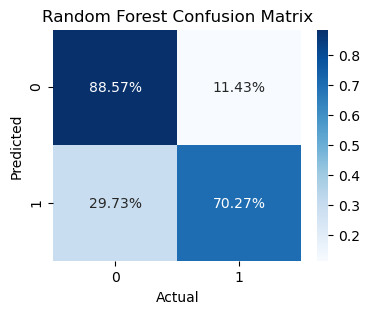

In [142]:
# Plot confusion matrix
# Normalize the confusion matrix to show percentages
plt.figure(figsize=(4, 3))
cm_normrf = conf_matrix_rf.astype('float') / conf_matrix_rf.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normrf, annot=True, fmt=".2%", cmap='Blues', xticklabels=['0', '1'], yticklabels=['0', '1'])
plt.ylabel('Predicted')
plt.xlabel('Actual')
plt.title('Random Forest Confusion Matrix')
plt.show()

In [143]:
# ROC Curve
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_predRF_probs)

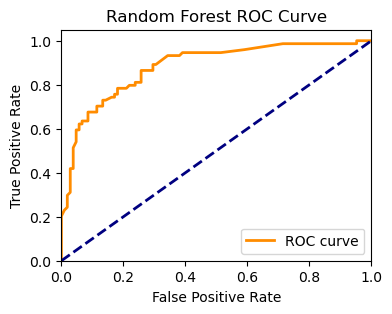

In [144]:
# Plot ROC Curve
plt.figure(figsize=(4, 3))
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, label='ROC curve')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest ROC Curve')
plt.legend(loc='lower right')
plt.show()

#### 5.3-Logistic Regression

In [145]:
#### Compute evaluation metrics ###
## Training 
# Accuracy: 
train_acc_lr = accuracy_score(y_train, train_preds_lr)
#precision
train_preci_lr = precision_score(y_train, train_preds_lr)
#recall 
train_recall_lr = recall_score(y_train, train_preds_lr)
# F1 score
train_f1_lr= f1_score(y_train, train_preds_lr)
# Classification Report
train_class_report_lr = classification_report(y_train, train_preds_lr)

## Testing
# Accuracy: 
acc_lr = accuracy_score(y_test, y_predLR) 
#precision
preci_lr = precision_score(y_test, y_predLR)
#recall 
recall_lr = recall_score(y_test, y_predLR)
# F1 score
f1_lr= f1_score(y_test, y_predLR)
# ROC Curve and AUC
auc_roc_lr= roc_auc_score(y_test, y_predLR_probs)
# Confusion Matrix
conf_matrix_lr = confusion_matrix(y_test, y_predLR)
# Classification Report
class_report_lr = classification_report(y_test, y_predLR)

In [146]:
# Print the metrics
print('**********************')
print('Logistic Regression Evaluation metrics')
print('**********************')
print('Training')
print('**********************')
print(f'Accuracy: {train_acc_lr}')
print(f'Precision: {train_preci_lr}')
print(f'Recall: {train_recall_lr}')
print(f'F1 Score: {train_f1_lr}')
print('**********************')
print('Testing')
print('**********************')
print(f'Accuracy: {acc_lr}')
print(f'Precision: {preci_lr}')
print(f'Recall: {recall_lr}')
print(f'F1 Score: {f1_lr}')
print(f'AUC-ROC: {auc_roc_lr}')
print(f'Confusion Matrix:\n{conf_matrix_lr}')
print(f'Classification Report:\n{class_report_lr}')

**********************
Logistic Regression Evaluation metrics
**********************
Training
**********************
Accuracy: 0.8019662921348315
Precision: 0.7613168724279835
Recall: 0.6902985074626866
F1 Score: 0.7240704500978473
**********************
Testing
**********************
Accuracy: 0.7932960893854749
Precision: 0.7681159420289855
Recall: 0.7162162162162162
F1 Score: 0.7412587412587412
AUC-ROC: 0.8783783783783784
Confusion Matrix:
[[89 16]
 [21 53]]
Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.85      0.83       105
           1       0.77      0.72      0.74        74

    accuracy                           0.79       179
   macro avg       0.79      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



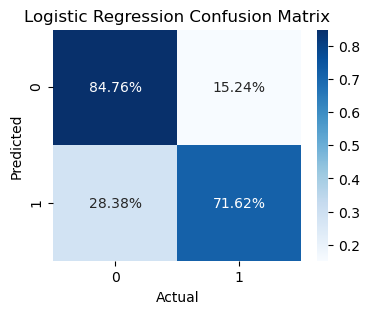

In [147]:
# Plot confusion matrix
# Normalize the confusion matrix to show percentages
plt.figure(figsize=(4, 3))
cm_normlr = conf_matrix_lr.astype('float') / conf_matrix_lr.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normlr, annot=True, fmt=".2%", cmap='Blues', xticklabels=['0', '1'], yticklabels=['0', '1'])
plt.ylabel('Predicted')
plt.xlabel('Actual')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

In [148]:
# ROC Curve
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, y_predLR_probs)

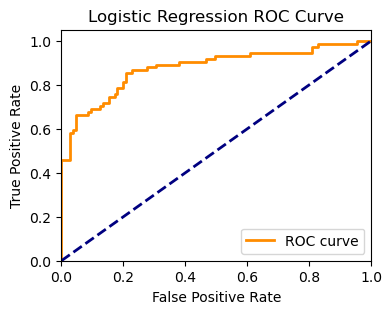

In [149]:
# Plot ROC Curve
plt.figure(figsize=(4, 3))
plt.plot(fpr_lr, tpr_lr, color='darkorange', lw=2, label='ROC curve')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression ROC Curve')
plt.legend(loc='lower right')
plt.show()

#### 5.4-Support Vector

In [150]:
#### Compute evaluation metrics ###
## Training 
# Accuracy: 
train_acc_svc = accuracy_score(y_train, train_preds_svc)
#precision
train_preci_svc = precision_score(y_train, train_preds_svc)
#recall 
train_recall_svc = recall_score(y_train, train_preds_svc)
# F1 score
train_f1_svc= f1_score(y_train, train_preds_svc)
# Classification Report
train_class_report_svc = classification_report(y_train, train_preds_svc)

## Testing
# Accuracy: 
acc_svc = accuracy_score(y_test, y_predSVC) 
#precision
preci_svc = precision_score(y_test, y_predSVC)
#recall 
recall_svc = recall_score(y_test, y_predSVC)
# F1 score
f1_svc= f1_score(y_test, y_predSVC)
# ROC Curve and AUC
auc_roc_svc = roc_auc_score(y_test, y_predsvc_probs)
# Confusion Matrix
conf_matrix_svc = confusion_matrix(y_test, y_predSVC)
# Classification Report
class_report_svc = classification_report(y_test, y_predSVC)

In [151]:
# Print the metrics
print('**********************')
print('Support Vector Machine Evaluation metrics')
print('**********************')
print('Training')
print('**********************')
print(f'Accuracy: {train_acc_svc}')
print(f'Precision: {train_preci_svc}')
print(f'Recall: {train_recall_svc}')
print(f'F1 Score: {train_f1_svc}')
print('**********************')
print('Testing')
print('**********************')
print(f'Accuracy: {acc_svc}')
print(f'Precision: {preci_svc}')
print(f'Recall: {recall_svc}')
print(f'F1 Score: {f1_lr}')
print(f'AUC-ROC: {auc_roc_svc}')
print(f'Confusion Matrix:\n{conf_matrix_svc}')
print(f'Classification Report:\n{class_report_svc}')

**********************
Support Vector Machine Evaluation metrics
**********************
Training
**********************
Accuracy: 0.8356741573033708
Precision: 0.8158995815899581
Recall: 0.7276119402985075
F1 Score: 0.7692307692307692
**********************
Testing
**********************
Accuracy: 0.8156424581005587
Precision: 0.8059701492537313
Recall: 0.7297297297297297
F1 Score: 0.7412587412587412
AUC-ROC: 0.8526383526383527
Confusion Matrix:
[[92 13]
 [20 54]]
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       105
           1       0.81      0.73      0.77        74

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.81       179
weighted avg       0.82      0.82      0.81       179



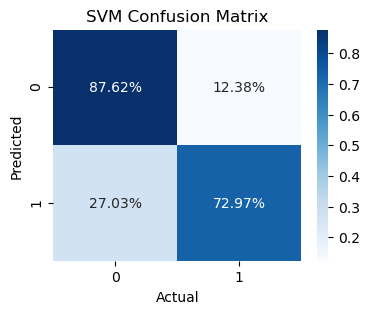

In [152]:
# Plot confusion matrix
# Normalize the confusion matrix to show percentages
plt.figure(figsize=(4, 3))
cm_normsvc = conf_matrix_svc.astype('float') / conf_matrix_svc.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normsvc, annot=True, fmt=".2%", cmap='Blues', xticklabels=['0', '1'], yticklabels=['0', '1'])
plt.ylabel('Predicted')
plt.xlabel('Actual')
plt.title('SVM Confusion Matrix')
plt.show()

In [153]:
# ROC Curve
fpr_svc, tpr_svc, thresholds_svc = roc_curve(y_test, y_predsvc_probs)

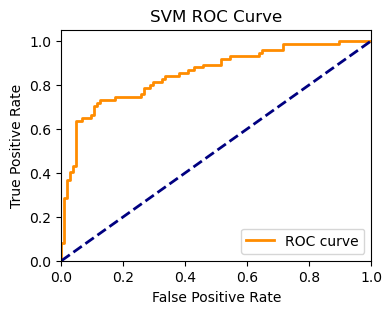

In [154]:
# Plot ROC Curve
plt.figure(figsize=(4, 3))
plt.plot(fpr_svc, tpr_svc, color='darkorange', lw=2, label='ROC curve')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('SVM ROC Curve')
plt.legend(loc='lower right')
plt.show()

#### 5.5- K-Nearest Neighbors

In [155]:
#### Compute evaluation metrics ###
## Training 
# Accuracy: 
train_acc_knn = accuracy_score(y_train, train_preds_knn)
#precision
train_preci_knn = precision_score(y_train, train_preds_knn)
#recall 
train_recall_knn = recall_score(y_train, train_preds_knn)
# F1 score
train_f1_knn= f1_score(y_train, train_preds_knn)
# Classification Report
train_class_report_knn = classification_report(y_train, train_preds_knn)

## Testing
# Accuracy: 
acc_knn = accuracy_score(y_test, y_predKNN) 
#precision
preci_knn = precision_score(y_test, y_predKNN)
#recall 
recall_knn = recall_score(y_test, y_predKNN)
# F1 score
f1_knn= f1_score(y_test, y_predKNN)
# ROC Curve and AUC
auc_roc_knn = roc_auc_score(y_test, y_predknn_probs)
# Confusion Matrix
conf_matrix_knn = confusion_matrix(y_test, y_predKNN)
# Classification Report
class_report_knn = classification_report(y_test, y_predKNN)

In [156]:
# Print the metrics
print('**********************')
print('K-Nearest Neighbors Evaluation metrics')
print('**********************')
print('Training')
print('**********************')
print(f'Accuracy: {train_acc_knn}')
print(f'Precision: {train_preci_knn}')
print(f'Recall: {train_recall_knn}')
print(f'F1 Score: {train_f1_knn}')
print('***********************')
print('Testing')
print('***********************')
print(f'Accuracy: {acc_knn}')
print(f'Precision: {preci_knn}')
print(f'Recall: {recall_knn}')
print(f'F1 Score: {f1_knn}')
print(f'AUC-ROC: {auc_roc_knn}')
print(f'Confusion Matrix:\n{conf_matrix_knn}')
print(f'Classification Report:\n{class_report_knn}')

**********************
K-Nearest Neighbors Evaluation metrics
**********************
Training
**********************
Accuracy: 0.8441011235955056
Precision: 0.8617511520737328
Recall: 0.6977611940298507
F1 Score: 0.7711340206185567
***********************
Testing
***********************
Accuracy: 0.8268156424581006
Precision: 0.8307692307692308
Recall: 0.7297297297297297
F1 Score: 0.7769784172661871
AUC-ROC: 0.9020592020592021
Confusion Matrix:
[[94 11]
 [20 54]]
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86       105
           1       0.83      0.73      0.78        74

    accuracy                           0.83       179
   macro avg       0.83      0.81      0.82       179
weighted avg       0.83      0.83      0.82       179



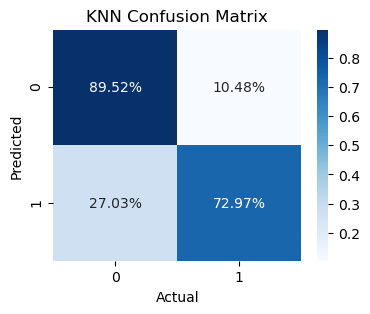

In [157]:
# Plot confusion matrix
# Normalize the confusion matrix to show percentages
plt.figure(figsize=(4, 3))
cm_normknn = conf_matrix_knn.astype('float') / conf_matrix_knn.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normknn, annot=True, fmt=".2%", cmap='Blues', xticklabels=['0', '1'], yticklabels=['0', '1'])
plt.ylabel('Predicted')
plt.xlabel('Actual')
plt.title('KNN Confusion Matrix')
plt.show()

In [158]:
# ROC Curve
fpr_knn, tpr_knn, thresholds_knn = roc_curve(y_test, y_predknn_probs)

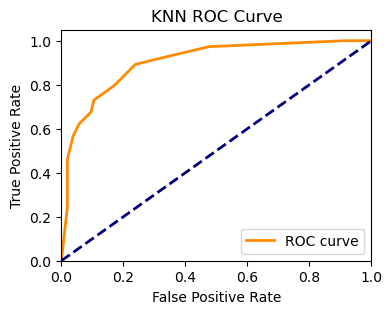

In [159]:
# Plot ROC Curve
plt.figure(figsize=(4, 3))
plt.plot(fpr_knn, tpr_knn, color='darkorange', lw=2, label='ROC curve')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('KNN ROC Curve')
plt.legend(loc='lower right')
plt.show()

#### 5.6- Confusion matrix visualisation

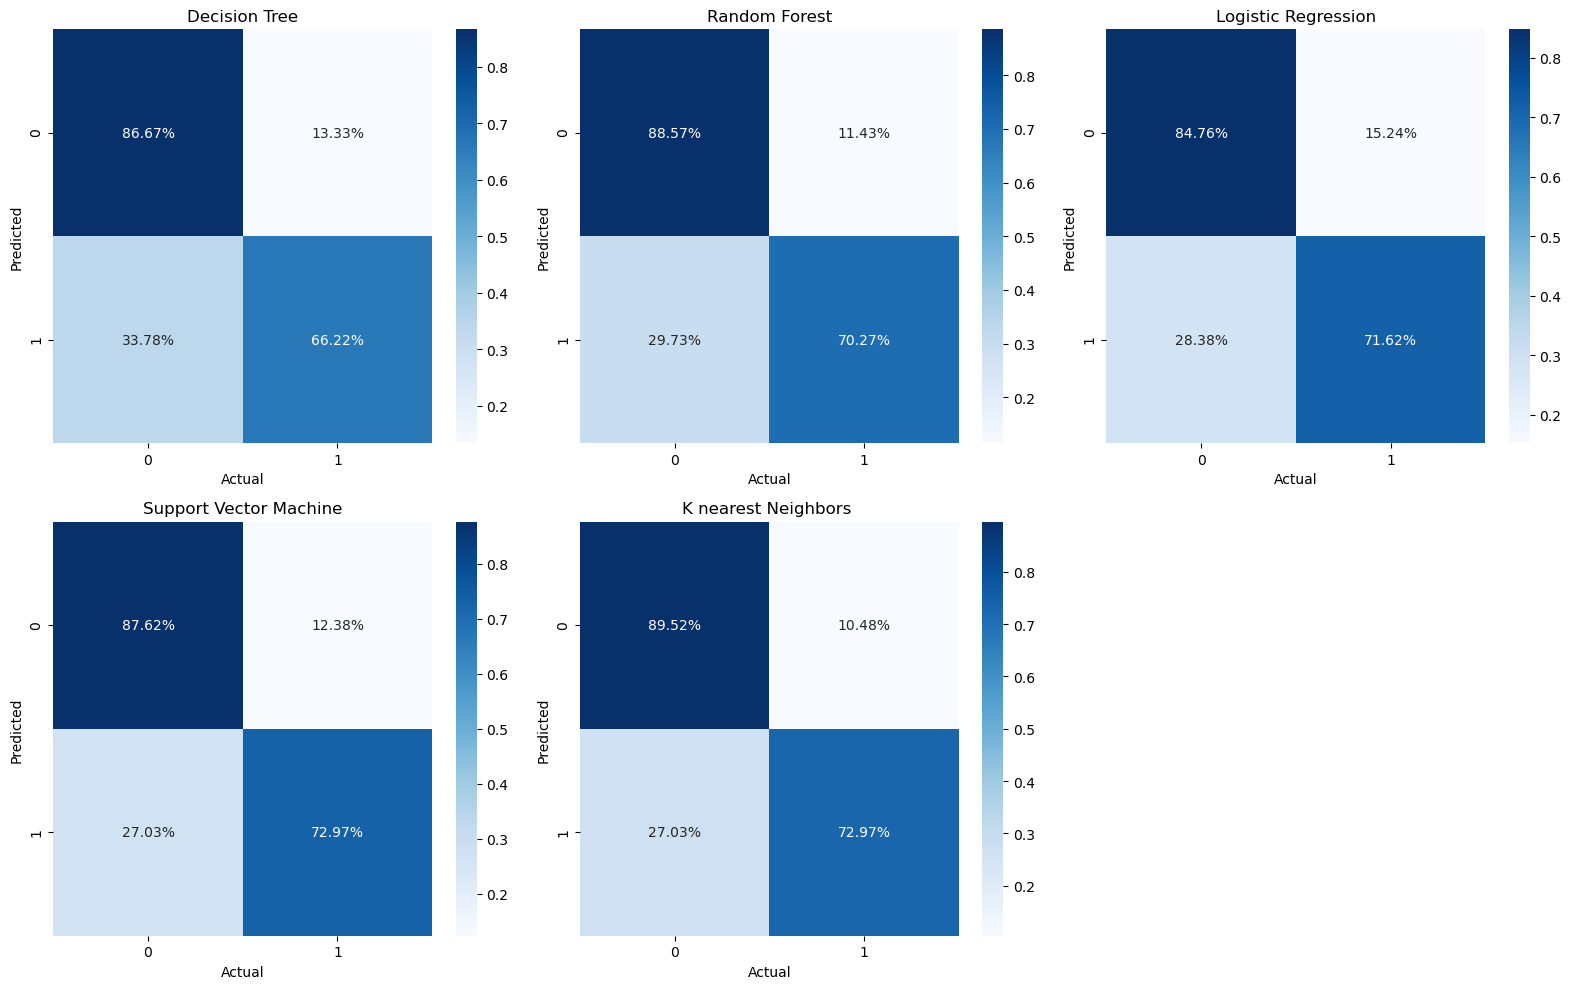

In [160]:
# Creating a figure with two subplots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
labels=['0', '1']
# Decision Tree
sns.heatmap(cm_normdt, annot=True, fmt=".2%", cmap='Blues',
              xticklabels=labels, yticklabels=labels , ax=axes[0, 0])
axes[0, 0].set_title('Decision Tree')
axes[0, 0].set_xlabel('Actual')
axes[0, 0].set_ylabel('Predicted')

# Random Forest
sns.heatmap(cm_normrf, annot=True, fmt=".2%", cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[0, 1])
axes[0, 1].set_title('Random Forest')
axes[0, 1].set_xlabel('Actual')
axes[0, 1].set_ylabel('Predicted')

# Logistic Regression 
sns.heatmap(cm_normlr, annot=True, fmt=".2%", cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[0, 2])
axes[0, 2].set_title('Logistic Regression')
axes[0, 2].set_xlabel('Actual')
axes[0, 2].set_ylabel('Predicted')

# Support vector Machine 
sns.heatmap(cm_normsvc, annot=True, fmt=".2%", cmap='Blues',
             xticklabels=labels, yticklabels=labels, ax=axes[1, 0])
axes[1, 0].set_title('Support Vector Machine')
axes[1, 0].set_xlabel('Actual')
axes[1, 0].set_ylabel('Predicted')

# K nearest Neighbors 
sns.heatmap(cm_normknn, annot=True, fmt=".2%", cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[1, 1])
axes[1, 1].set_title('K nearest Neighbors ')
axes[1, 1].set_xlabel('Actual')
axes[1, 1].set_ylabel('Predicted')
# Hide the empty subplot
axes[1, 2].axis('off')
# Adjust layout
plt.tight_layout()
plt.show()

#### 5.7- ROC-AUC Curve 

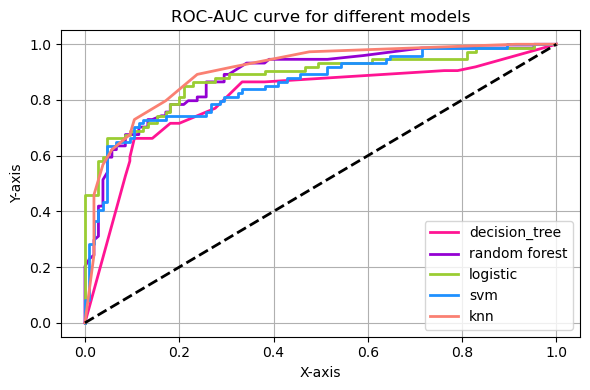

In [161]:
# Create a single figure and axis
fig, ax = plt.subplots(figsize=(6, 4))
# Plotting multiple lines on the same axes
# Decision trees
ax.plot(fpr_dt, tpr_dt, color='deeppink', lw=2, label='decision_tree')
# Random Forest
ax.plot(fpr_rf, tpr_rf, color='darkviolet', lw=2, label='random forest')
# Logistic Regression
ax.plot(fpr_lr, tpr_lr, color='yellowgreen', lw=2, label='logistic')
# SVM
ax.plot(fpr_svc, tpr_svc, color='dodgerblue', lw=2, label='svm')
# KNN
ax.plot(fpr_knn, tpr_knn, color='salmon', lw=2, label='knn')
ax.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')
# Adding title, labels, and legend
ax.set_title('ROC-AUC curve for different models')
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.legend()

# Show plot
plt.tight_layout()
plt.grid()
plt.show()

#### 5.7- Overfitting/underfitting verification
- It is crucial to verify whether the model is overfitting or not to ensure that the model generalizes well to unseen data and is not just fitting to the training data.
- I have used `GridSearchCV` with cv=5 which helps mitigate the risk of overfitting.
- However, it does not completely eliminate it because the model overfitting depends on several factors such as model complexity, data preprocessing steps (like scaling or imputation) if they are not properly handled within each fold. 


| Data | Accuracy(%) | Precision(%) |Recall(%) |F1 Score(%) |
| --- | --- | --- |--- |--- |
| **Decision Trees** |
| Train | 88 | 95 |  73| 83 |
| Test | 78 | 78 | 66 |72  |
|**Random Forest**|
| Train | 85 | 88 |  71| 76 |
| Test | 81 | 81 | 70 | 75 |
| **Logistic Regression** |
| Train | 80 | 76 | 69 |72  |
| Test |79 | 77 | 72 | 74 |
| **Support Vector Machine** |
| Train | 84 | 82 | 73 | 77 |
| Test |82 | 81 | 73 | 74 |
| **K-Nearest Neighbors** |
| Train | 84 | 86 | 70 | 77 |
| Test |83 | 83 | 73 | 78 |


- Desipite the usage of `GridSearchCV` with `cross-validation (cv=5)`, it seems that single decision tree model might be overfitting as there is a significant drop in performance from training to testing, especially in accuracy and precision. This indicates that the generated model performs well on the training data but struggles to generalize to unseen data. 
- To address this issue and improve generalization, I decided to use Random Forest where prediction is made using multiple models.
- For Random Forest, the model is performing well and does not exhibit significant signs of overfitting or underfitting which means it is a well-balanced and effective model for this binary classification task.
- Based on the results above, the three models Logistic Regression, SVM and KNN demonstrate good performance without signs of overfitting or underfitting. Again, they appear to be well-balanced and effective for this binary classification task. 


### 6. Communication and Reporting 💬 📊

- **Why I Decided Not to Resolve Class Imbalance via Upsampling for the Minority Class:**
  - My dataset is mildly imbalanced, but it is not highly imbalanced as the ratio of class 'Died' to class 'Suvived'  is approximately 1:1.6. This means for every sample of class 'Suvived', there are 1.6 samples of class 'Died'.
  - My models did not perform poorly on the minority class (class 1)
  - The confusion matrix confirms that the model effectively avoids misclassifying the minority class, with precision ranging from 77% to 81%. Moreover, recall falls within the range of 66% to 73%.
  - The ROC-AUC scores for all models range from 80% to 90%, indicating robust capability in distinguishing between the positive and negative classes.

### 6.1- Results Interpretation ⁉️🧠

| Model | Accuracy(%) | Precision(%) |Recall(%) |F1 Score(%) |
| --- | --- | --- |--- |--- |
| Decision Trees | 78 | 78 | 66 |72  |
| Random Forest | 81 | 81 | 70 | 75 |
| Logistic Regression | 79 | 77 | 72 | 74 |
| SVM | 82 | 81 | 73 | 74 |
| KNN | 83 | 83 | 73 | 78 |

- All the models show consistent performance with accuracy ranging from 78% to 83%, indicating they are generally reliable in making correct predictions across all classes.
- Precision scores varying between 77% and 83% suggest that the models are capable of accurately predicting positive instances, with minimal false positives.
- Recall rates between 66% and 73% indicate the models effectively capture true positive instances, though there may be some missed positive cases.
- F1-scores ranging from 72% to 78% demonstrate a good balance between precision and recall, reflecting overall robust performance across the models.
  
- In summary, all the found models perform well, demonstrating high accuracy and balanced precision-recall trade-offs in their predictions.


### Which algorithm should I choose for deployment? 💡
- Based on the Table above, I will choose KNN as it appears to be the best model overall due to its highest accuracy, precision, and F1-score.✅
- In addition, based on the ROC-AUC (last plot) it is evident that KNN is the best model among others

### 7. Model Deployment 🎯🚀
- This step involves completing the final stage of deploying a machine learning model to ensure that the machine learning model is successfully deployed and operational in a production environment.
- Here is the list of subtasks:
  - Setting up Deployment Environment : ensures that it includes all necessary libraries and dependencies.
  - Upload the trained model file to the deployment environment or cloud platform.
  - Establish an API endpoint or web interface that allows users to interact with the model.
  - Conduct complete testing to verify the model's functionality and performance in the deployment environment.
  - Implement monitoring mechanisms to track the model's performance and detect any issues or anomalies.
  - Regularly update and maintain the model to ensure continued accuracy and efficiency.